# 04 — Canonical Damaged-Image Generation

This notebook applies the canonical synthetic damage masks from Notebook 03 to the preprocessed clean painting images.

## Method

For each canonical mask case:

1. load the clean RGB painting;
2. load the corresponding binary mask;
3. replace masked pixels using the configured damage-fill strategy;
4. preserve all pixels outside the mask;
5. save the damaged image as a canonical RGB PNG;
6. record paths, damaged-area measurements, fill settings, provenance, file metadata, and checksums;
7. reload and validate every saved output;
8. audit completeness, duplicates, stale files, missing files, and orphaned files.

## Canonical inputs

- `data/processed/clean/*.png`
- `data/processed/metadata/metadata_processed_clean.csv`
- `data/processed/masks/*.png`
- `data/processed/metadata/metadata_masks.csv`

## Canonical outputs

- `data/processed/damaged/*.png`
- `data/processed/metadata/metadata_damaged_images.csv`
- `outputs/04_damage_creation/damage_creation_audit.csv`
- `outputs/figures/damage_creation/*.png`
- `outputs/reports/damage_creation_metadata.json`
- `outputs/reports/damage_creation_report.md`

In [1]:
from pathlib import Path
import sys
import yaml


def find_project_root(
    start_path: Path,
) -> Path:
    current_path = start_path.resolve()

    for candidate_path in [
        current_path,
        *current_path.parents,
    ]:
        if (
            (candidate_path / "config").is_dir()
            and (candidate_path / "src").is_dir()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Expected a parent directory containing "
        "both 'config/' and 'src/'."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"

EXPERIMENT_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)


if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


if not EXPERIMENT_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Experiment configuration was not found: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


print("Environment configured")
print("----------------------")
print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print(
    "Experiment configuration:",
    EXPERIMENT_CONFIG_PATH,
)

Environment configured
----------------------
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Experiment configuration: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml


In [2]:
import hashlib
import json
import shutil
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from restoration_eval.damage import (
    DEFAULT_DAMAGE_FILL_COLOR,
    DEFAULT_DAMAGE_FILL_STRATEGY,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    SUPPORTED_DAMAGE_FILL_STRATEGIES,
    audit_damaged_inventory,
    create_damaged_images_for_dataset,
    validate_damage_application,
    validate_damaged_images,
)


with EXPERIMENT_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as configuration_file:
    experiment_config = yaml.safe_load(
        configuration_file
    )


if not isinstance(
    experiment_config,
    dict,
):
    raise ValueError(
        "Configuration must contain a YAML mapping: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


required_config_sections = [
    "experiment",
    "paths",
    "dataset",
    "preprocessing",
    "masks",
]


missing_config_sections = [
    section_name
    for section_name in required_config_sections
    if section_name not in experiment_config
]


if missing_config_sections:
    raise ValueError(
        "Configuration is missing required sections: "
        f"{missing_config_sections}"
    )


config_version = str(
    experiment_config.get(
        "config_version",
        "unversioned",
    )
)

experiment_config_section = (
    experiment_config["experiment"]
)

paths_config = experiment_config["paths"]

dataset_config = experiment_config["dataset"]

preprocessing_config = (
    experiment_config["preprocessing"]
)

mask_config = experiment_config["masks"]

damage_config = experiment_config.get(
    "damage",
    {},
)


experiment_name = str(
    experiment_config_section.get(
        "name",
        "unnamed_experiment",
    )
)

experiment_version = str(
    experiment_config_section.get(
        "version",
        "unversioned",
    )
)


processed_metadata_dir = (
    PROJECT_ROOT
    / paths_config[
        "processed_metadata_dir"
    ]
)

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

mask_metadata_path = (
    processed_metadata_dir
    / "metadata_masks.csv"
)

damaged_metadata_path = (
    processed_metadata_dir
    / "metadata_damaged_images.csv"
)


clean_image_dir = (
    PROJECT_ROOT
    / paths_config["clean_dir"]
)

mask_image_dir = (
    PROJECT_ROOT
    / paths_config["mask_dir"]
)

damaged_image_dir = (
    PROJECT_ROOT
    / paths_config["masked_dir"]
)


damage_creation_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "04_damage_creation"
)

damage_figure_dir = (
    PROJECT_ROOT
    / paths_config["figures_dir"]
    / "damage_creation"
)

report_output_dir = (
    PROJECT_ROOT
    / paths_config["reports_dir"]
)


temporary_damage_test_dir = (
    damage_creation_output_dir
    / "tmp_generation_test"
)


damage_creation_audit_path = (
    damage_creation_output_dir
    / "damage_creation_audit.csv"
)

damage_manifest_path = (
    report_output_dir
    / "damage_creation_metadata.json"
)

damage_report_path = (
    report_output_dir
    / "damage_creation_report.md"
)


target_size = int(
    preprocessing_config.get(
        "output_size",
        experiment_config_section.get(
            "image_size",
            768,
        ),
    )
)

expected_painting_count = int(
    dataset_config.get(
        "total_paintings",
        50,
    )
)

configured_mask_types = list(
    mask_config.get(
        "mask_types",
        [],
    )
)

expected_mask_type_count = len(
    configured_mask_types
)

expected_case_count = (
    expected_painting_count
    * expected_mask_type_count
)


damage_fill_strategy = str(
    damage_config.get(
        "fill_strategy",
        DEFAULT_DAMAGE_FILL_STRATEGY,
    )
)

configured_damage_fill_color = (
    damage_config.get(
        "fill_color_rgb",
        DEFAULT_DAMAGE_FILL_COLOR,
    )
)

damage_fill_color = tuple(
    int(channel_value)
    for channel_value
    in configured_damage_fill_color
)


damage_generator_name = str(
    damage_config.get(
        "generator_name",
        GENERATOR_NAME,
    )
)

damage_generator_version = str(
    damage_config.get(
        "generator_version",
        GENERATOR_VERSION,
    )
)


required_input_paths = [
    processed_metadata_path,
    mask_metadata_path,
    clean_image_dir,
    mask_image_dir,
]


missing_input_paths = [
    input_path
    for input_path in required_input_paths
    if not input_path.exists()
]


if missing_input_paths:
    raise FileNotFoundError(
        "Required Notebook 04 inputs are missing: "
        f"{missing_input_paths}"
    )


if not configured_mask_types:
    raise ValueError(
        "No mask types are configured in the "
        "'masks.mask_types' YAML setting."
    )


if (
    damage_fill_strategy
    not in SUPPORTED_DAMAGE_FILL_STRATEGIES
):
    raise ValueError(
        "Unsupported damage-fill strategy: "
        f"{damage_fill_strategy!r}. "
        "Supported strategies: "
        f"{list(SUPPORTED_DAMAGE_FILL_STRATEGIES)}"
    )


if len(damage_fill_color) != 3:
    raise ValueError(
        "Damage fill colour must contain exactly "
        "three RGB channel values."
    )


if any(
    channel_value < 0
    or channel_value > 255
    for channel_value in damage_fill_color
):
    raise ValueError(
        "Damage fill RGB values must lie "
        "between 0 and 255."
    )


if damage_generator_name != GENERATOR_NAME:
    raise ValueError(
        "Configured damage generator name does "
        "not match the implementation: "
        f"config={damage_generator_name!r}, "
        f"implementation={GENERATOR_NAME!r}"
    )


if damage_generator_version != GENERATOR_VERSION:
    raise ValueError(
        "Configured damage generator version does "
        "not match the implementation: "
        f"config={damage_generator_version!r}, "
        f"implementation={GENERATOR_VERSION!r}"
    )


for output_directory in [
    processed_metadata_dir,
    damaged_image_dir,
    damage_creation_output_dir,
    damage_figure_dir,
    report_output_dir,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

mask_metadata_df = pd.read_csv(
    mask_metadata_path
)


print("Configuration loaded")
print("--------------------")
print("Config version:", config_version)
print("Experiment:", experiment_name)
print(
    "Experiment version:",
    experiment_version,
)
print(
    "Damage generator:",
    damage_generator_name,
)
print(
    "Damage generator version:",
    damage_generator_version,
)
print("Target image size:", target_size)
print(
    "Expected paintings:",
    expected_painting_count,
)
print(
    "Configured mask types:",
    configured_mask_types,
)
print(
    "Expected damage cases:",
    expected_case_count,
)
print(
    "Fill strategy:",
    damage_fill_strategy,
)
print(
    "Fill colour RGB:",
    damage_fill_color,
)


print("\nResolved input paths")
print("--------------------")
print(
    "Processed metadata:",
    processed_metadata_path,
)
print("Mask metadata:", mask_metadata_path)
print("Clean images:", clean_image_dir)
print("Masks:", mask_image_dir)


print("\nResolved output paths")
print("---------------------")
print(
    "Damaged images:",
    damaged_image_dir,
)
print(
    "Damaged metadata:",
    damaged_metadata_path,
)
print(
    "Notebook output:",
    damage_creation_output_dir,
)
print("Figures:", damage_figure_dir)
print("Reports:", report_output_dir)


print("\nLoaded metadata")
print("---------------")
print(
    "Processed metadata shape:",
    processed_metadata_df.shape,
)
print(
    "Mask metadata shape:",
    mask_metadata_df.shape,
)

display(
    processed_metadata_df.head()
)

display(
    mask_metadata_df.head()
)

Configuration loaded
--------------------
Config version: 1.1.0
Experiment: painting_restoration_50_subset
Experiment version: 1.0.0
Damage generator: canonical_damage_generator
Damage generator version: 2.0.0
Target image size: 768
Expected paintings: 50
Configured mask types: ['zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage']
Expected damage cases: 250
Fill strategy: white_fill
Fill colour RGB: (255, 255, 255)

Resolved input paths
--------------------
Processed metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Mask metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv
Clean images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\clean
Masks: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks

Resolved output paths
---------------------
Damaged images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masked
Dam

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


,case_id,painting_id,mask_id,mask_type,mask_type_index,mask_filename,mask_path,generator_name,generator_version,config_version,...,area_distance_to_allowed_range_pct,area_within_target_tolerance,generation_status,unique_pixel_values,binary_values_valid,zero_control_rule_valid,content_only_valid,generation_valid,status,issue
0,p001_zero_control,p001,p001_zero_control,zero_control,0,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0,True,True,True,True,ok,NaN
1,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,1,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
2,p001_loss_small,p001,p001_loss_small,loss_small,2,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
3,p001_loss_large,p001,p001_loss_large,loss_large,3,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN
4,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,4,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,canonical_synthetic_damage_masks,2.0.0,1.1.0,...,0.0,True,ok,0|255,True,True,True,True,ok,NaN


In [3]:
# Validate canonical metadata and source files before damage generation

required_processed_columns = [
    "painting_id",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
]

required_mask_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_filename",
    "mask_path",
    "actual_mask_area_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
]


missing_processed_columns = [
    column_name
    for column_name in required_processed_columns
    if column_name not in processed_metadata_df.columns
]

missing_mask_columns = [
    column_name
    for column_name in required_mask_columns
    if column_name not in mask_metadata_df.columns
]


if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )


if missing_mask_columns:
    raise ValueError(
        "Mask metadata is missing required columns: "
        f"{missing_mask_columns}"
    )


processed_duplicate_painting_rows = (
    processed_metadata_df[
        "painting_id"
    ].duplicated(
        keep=False
    )
)

mask_duplicate_case_rows = (
    mask_metadata_df[
        "case_id"
    ].duplicated(
        keep=False
    )
)

mask_duplicate_id_rows = (
    mask_metadata_df[
        "mask_id"
    ].duplicated(
        keep=False
    )
)

mask_duplicate_filename_rows = (
    mask_metadata_df[
        "mask_filename"
    ].duplicated(
        keep=False
    )
)


processed_painting_ids = set(
    processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

mask_painting_ids = set(
    mask_metadata_df[
        "painting_id"
    ]
    .astype(str)
)


masks_without_processed_paintings = sorted(
    mask_painting_ids
    - processed_painting_ids
)

processed_paintings_without_masks = sorted(
    processed_painting_ids
    - mask_painting_ids
)


observed_mask_types = (
    mask_metadata_df[
        "mask_type"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


missing_configured_mask_types = [
    mask_type
    for mask_type in configured_mask_types
    if mask_type not in observed_mask_types
]

unexpected_mask_types = [
    mask_type
    for mask_type in observed_mask_types
    if mask_type not in configured_mask_types
]


mask_type_count_df = (
    mask_metadata_df[
        "mask_type"
    ]
    .value_counts()
    .reindex(
        configured_mask_types,
        fill_value=0,
    )
    .rename_axis("mask_type")
    .reset_index(name="case_count")
)


invalid_mask_type_count_rows = (
    mask_type_count_df.loc[
        mask_type_count_df[
            "case_count"
        ]
        != expected_painting_count
    ]
    .copy()
)


processed_dimension_failure_rows = (
    processed_metadata_df.loc[
        (
            processed_metadata_df[
                "processed_width"
            ].astype(int)
            != target_size
        )
        |
        (
            processed_metadata_df[
                "processed_height"
            ].astype(int)
            != target_size
        )
    ]
    .copy()
)


missing_clean_file_records = []


for processed_row in (
    processed_metadata_df.itertuples(
        index=False
    )
):
    clean_image_path = Path(
        str(
            processed_row.processed_path
        )
    )

    if not clean_image_path.is_absolute():
        clean_image_path = (
            PROJECT_ROOT
            / clean_image_path
        )

    if not clean_image_path.exists():
        missing_clean_file_records.append(
            {
                "painting_id": str(
                    processed_row.painting_id
                ),
                "clean_image_path": str(
                    clean_image_path
                ),
            }
        )


missing_mask_file_records = []


for mask_row in mask_metadata_df.itertuples(
    index=False
):
    mask_image_path = Path(
        str(mask_row.mask_path)
    )

    if not mask_image_path.is_absolute():
        mask_image_path = (
            PROJECT_ROOT
            / mask_image_path
        )

    if not mask_image_path.exists():
        missing_mask_file_records.append(
            {
                "case_id": str(
                    mask_row.case_id
                ),
                "mask_image_path": str(
                    mask_image_path
                ),
            }
        )


metadata_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "processed_metadata_rows",
            "observed": len(
                processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(processed_metadata_df)
                == expected_painting_count
            ),
        },
        {
            "check": "mask_metadata_rows",
            "observed": len(
                mask_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(mask_metadata_df)
                == expected_case_count
            ),
        },
        {
            "check": (
                "unique_processed_painting_ids"
            ),
            "observed": int(
                processed_duplicate_painting_rows.sum()
            ),
            "expected": 0,
            "passed": bool(
                not processed_duplicate_painting_rows.any()
            ),
        },
        {
            "check": "unique_mask_case_ids",
            "observed": int(
                mask_duplicate_case_rows.sum()
            ),
            "expected": 0,
            "passed": bool(
                not mask_duplicate_case_rows.any()
            ),
        },
        {
            "check": "unique_mask_ids",
            "observed": int(
                mask_duplicate_id_rows.sum()
            ),
            "expected": 0,
            "passed": bool(
                not mask_duplicate_id_rows.any()
            ),
        },
        {
            "check": "unique_mask_filenames",
            "observed": int(
                mask_duplicate_filename_rows.sum()
            ),
            "expected": 0,
            "passed": bool(
                not mask_duplicate_filename_rows.any()
            ),
        },
        {
            "check": "painting_id_coverage",
            "observed": (
                len(
                    masks_without_processed_paintings
                )
                + len(
                    processed_paintings_without_masks
                )
            ),
            "expected": 0,
            "passed": bool(
                not masks_without_processed_paintings
                and not processed_paintings_without_masks
            ),
        },
        {
            "check": "configured_mask_type_set",
            "observed": len(
                observed_mask_types
            ),
            "expected": (
                expected_mask_type_count
            ),
            "passed": bool(
                not missing_configured_mask_types
                and not unexpected_mask_types
            ),
        },
        {
            "check": "cases_per_mask_type",
            "observed": len(
                invalid_mask_type_count_rows
            ),
            "expected": 0,
            "passed": (
                invalid_mask_type_count_rows.empty
            ),
        },
        {
            "check": "processed_dimensions",
            "observed": len(
                processed_dimension_failure_rows
            ),
            "expected": 0,
            "passed": (
                processed_dimension_failure_rows.empty
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_file_records
            ),
            "expected": 0,
            "passed": (
                not missing_clean_file_records
            ),
        },
        {
            "check": "missing_mask_files",
            "observed": len(
                missing_mask_file_records
            ),
            "expected": 0,
            "passed": (
                not missing_mask_file_records
            ),
        },
    ]
)


print("Canonical input gate")
print("--------------------")

display(metadata_gate_summary_df)


print("\nMask-type counts")
print("----------------")

display(mask_type_count_df)


failed_metadata_gate_df = (
    metadata_gate_summary_df.loc[
        ~metadata_gate_summary_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not invalid_mask_type_count_rows.empty:
    print(
        "\nInvalid mask-type counts"
    )
    display(
        invalid_mask_type_count_rows
    )


if not processed_dimension_failure_rows.empty:
    print(
        "\nProcessed dimension failures"
    )
    display(
        processed_dimension_failure_rows
    )


if missing_clean_file_records:
    print("\nMissing clean-image files")
    display(
        pd.DataFrame(
            missing_clean_file_records
        )
    )


if missing_mask_file_records:
    print("\nMissing mask files")
    display(
        pd.DataFrame(
            missing_mask_file_records
        )
    )


if masks_without_processed_paintings:
    print(
        "\nMasks without processed paintings:",
        masks_without_processed_paintings,
    )


if processed_paintings_without_masks:
    print(
        "\nProcessed paintings without masks:",
        processed_paintings_without_masks,
    )


if missing_configured_mask_types:
    print(
        "\nMissing configured mask types:",
        missing_configured_mask_types,
    )


if unexpected_mask_types:
    print(
        "\nUnexpected mask types:",
        unexpected_mask_types,
    )


if not failed_metadata_gate_df.empty:
    display(
        failed_metadata_gate_df
    )

    raise RuntimeError(
        "Canonical Notebook 04 input gate failed."
    )


print(
    "\nCanonical Notebook 04 input gate passed."
)

Canonical input gate
--------------------


,check,observed,expected,passed
0,processed_metadata_rows,50,50,True
1,mask_metadata_rows,250,250,True
2,unique_processed_painting_ids,0,0,True
3,unique_mask_case_ids,0,0,True
4,unique_mask_ids,0,0,True
5,unique_mask_filenames,0,0,True
6,painting_id_coverage,0,0,True
7,configured_mask_type_set,5,5,True
8,cases_per_mask_type,0,0,True
9,processed_dimensions,0,0,True



Mask-type counts
----------------


,mask_type,case_count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Canonical Notebook 04 input gate passed.


In [4]:
# Run a one-painting canonical damage-generation test

if temporary_damage_test_dir.exists():
    shutil.rmtree(
        temporary_damage_test_dir
    )


temporary_damage_test_dir.mkdir(
    parents=True,
    exist_ok=True,
)


test_painting_id = str(
    processed_metadata_df
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .iloc[0]["painting_id"]
)


test_processed_metadata_df = (
    processed_metadata_df.loc[
        processed_metadata_df[
            "painting_id"
        ].astype(str)
        == test_painting_id
    ]
    .copy()
)


test_mask_metadata_df = (
    mask_metadata_df.loc[
        mask_metadata_df[
            "painting_id"
        ].astype(str)
        == test_painting_id
    ]
    .copy()
)


test_mask_metadata_df[
    "mask_type"
] = pd.Categorical(
    test_mask_metadata_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


test_mask_metadata_df = (
    test_mask_metadata_df
    .sort_values(
        [
            "mask_type",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


print(
    "Test painting ID:",
    test_painting_id,
)


processed_display_columns = [
    column_name
    for column_name in [
        "painting_id",
        "category",
        "title",
        "processed_filename",
        "processed_path",
    ]
    if column_name
    in test_processed_metadata_df.columns
]


display(
    test_processed_metadata_df[
        processed_display_columns
    ]
)


display(
    test_mask_metadata_df[
        [
            "case_id",
            "mask_id",
            "mask_type",
            "mask_filename",
            "actual_mask_area_pixels",
            "actual_mask_area_percentage_content",
        ]
    ]
)


if len(test_processed_metadata_df) != 1:
    raise RuntimeError(
        "The one-painting test did not resolve "
        "to exactly one processed metadata row."
    )


if (
    len(test_mask_metadata_df)
    != expected_mask_type_count
):
    raise RuntimeError(
        "The one-painting test did not resolve "
        "to exactly one mask per configured mask type."
    )


observed_test_mask_types = (
    test_mask_metadata_df[
        "mask_type"
    ]
    .astype("object")
    .astype(str)
    .tolist()
)


if (
    observed_test_mask_types
    != configured_mask_types
):
    raise RuntimeError(
        "The one-painting test mask types do not "
        "match the configured mask-type order. "
        f"Observed: {observed_test_mask_types}; "
        f"expected: {configured_mask_types}"
    )


test_damaged_metadata_df = (
    create_damaged_images_for_dataset(
        processed_metadata=(
            test_processed_metadata_df
        ),
        mask_metadata=(
            test_mask_metadata_df
        ),
        clean_dir=clean_image_dir,
        damaged_dir=(
            temporary_damage_test_dir
        ),
        fill_color=damage_fill_color,
        fill_strategy=damage_fill_strategy,
        project_root=PROJECT_ROOT,
        overwrite=True,
        compute_checksums=True,
    )
)


print(
    "\nGenerated test damaged images:",
    len(test_damaged_metadata_df),
)


print("\nGeneration status")
print("-----------------")

display(
    test_damaged_metadata_df[
        "status"
    ]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)


test_file_validation_df = (
    validate_damaged_images(
        damaged_metadata=(
            test_damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)


test_application_validation_df = (
    validate_damage_application(
        damaged_metadata=(
            test_damaged_metadata_df
        ),
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_source_checksums=True,
    )
)


print("\nSaved-file validation")
print("---------------------")

display(test_file_validation_df)


print("\nDamage-application validation")
print("-----------------------------")

display(
    test_application_validation_df
)


test_generation_failed = bool(
    test_damaged_metadata_df[
        "status"
    ]
    .ne("ok")
    .any()
)


test_file_validation_failed = bool(
    ~test_file_validation_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
)


test_application_validation_failed = bool(
    ~test_application_validation_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
)


if test_generation_failed:
    failed_test_generation_df = (
        test_damaged_metadata_df.loc[
            test_damaged_metadata_df[
                "status"
            ]
            != "ok"
        ]
        .copy()
    )

    display(
        failed_test_generation_df
    )

    raise RuntimeError(
        "The one-painting damage-generation "
        "test failed."
    )


if test_file_validation_failed:
    failed_test_file_validation_df = (
        test_file_validation_df.loc[
            ~test_file_validation_df[
                "validation_passed"
            ].astype(bool)
        ]
        .copy()
    )

    display(
        failed_test_file_validation_df
    )

    raise RuntimeError(
        "The one-painting saved-file "
        "validation failed."
    )


if test_application_validation_failed:
    failed_test_application_validation_df = (
        test_application_validation_df.loc[
            ~test_application_validation_df[
                "validation_passed"
            ].astype(bool)
        ]
        .copy()
    )

    display(
        failed_test_application_validation_df
    )

    raise RuntimeError(
        "The one-painting damage-application "
        "validation failed."
    )


if (
    len(test_damaged_metadata_df)
    != expected_mask_type_count
):
    raise RuntimeError(
        "The one-painting test did not produce "
        "one damaged image for every configured "
        "mask type."
    )


print(
    "\nOne-painting canonical "
    "damage-generation test passed."
)

Test painting ID: p001


,painting_id,category,title,processed_filename,processed_path
0,p001,portrait_figure,Juan de Pareja,p001_clean.png,data/processed/clean/p001_clean.png


,case_id,mask_id,mask_type,mask_filename,actual_mask_area_pixels,actual_mask_area_percentage_content
0,p001_zero_control,p001_zero_control,zero_control,p001_zero_control_mask.png,0,0.000000
1,p001_scratch_thin,p001_scratch_thin,scratch_thin,p001_scratch_thin_mask.png,12058,2.368103
2,p001_loss_small,p001_loss_small,loss_small,p001_loss_small_mask.png,18239,3.582006
3,p001_loss_large,p001_loss_large,loss_large,p001_loss_large_mask.png,69018,13.554629
4,p001_mixed_damage,p001_mixed_damage,mixed_damage,p001_mixed_damage_mask.png,45733,8.981626



Generated test damaged images: 5

Generation status
-----------------


,status,count
0,ok,5



Saved-file validation
---------------------


,case_id,painting_id,mask_type,damaged_path,file_exists,readable,width,height,mode,format,file_size_bytes,filename_matches_metadata,calculated_damaged_sha256,issue_count,validation_passed,issue
0,p001_zero_control,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,723881,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0,True,
1,p001_scratch_thin,p001,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,728164,True,7d2e0affa9d97493f34263767ed46cce8d5df73a74caa2...,0,True,
2,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,704339,True,d8cb0269b9074b0e596d3ef817ab3c98ec1838b06457dd...,0,True,
3,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,631126,True,b7d7bd4dc2c427bc58c96a397bb24defe2f34945ad8114...,0,True,
4,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,675436,True,e5a985ef19e47ab186d825692ca24efbea810c3bd1391a...,0,True,



Damage-application validation
-----------------------------


,case_id,painting_id,mask_type,outside_mask_changed_pixels,inside_mask_not_fill_pixels,total_mask_pixels,metadata_mask_pixels,mask_pixel_count_difference,changed_pixel_count,unchanged_mask_pixel_count,expected_changeable_mask_pixels,changed_pixel_count_difference,clean_equals_damaged,outside_preservation_valid,fill_application_valid,calculated_clean_sha256,calculated_mask_sha256,issue_count,validation_passed,issue
0,p001_zero_control,p001,zero_control,0,0,0,0,0,0,0,0,0,True,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,49e2b0f2e0dc8fe44017bdabfa19ff50311b0bdd176233...,0,True,
1,p001_scratch_thin,p001,scratch_thin,0,0,12058,12058,0,12058,0,12058,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,14dc08421a7e8d5a5f8f96825a2161b6295cd41a98e48a...,0,True,
2,p001_loss_small,p001,loss_small,0,0,18239,18239,0,18239,0,18239,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,3b1600dab63bd0ee34f019c51e988b02bb43cb193d8930...,0,True,
3,p001_loss_large,p001,loss_large,0,0,69018,69018,0,69018,0,69018,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0c3aa0f9d930a7b8405439b8ec04e899f72bbe219472b0...,0,True,
4,p001_mixed_damage,p001,mixed_damage,0,0,45733,45733,0,45733,0,45733,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,66aa435e3d05dd8f922f95a0065ef7b626192d8a1e9833...,0,True,



One-painting canonical damage-generation test passed.


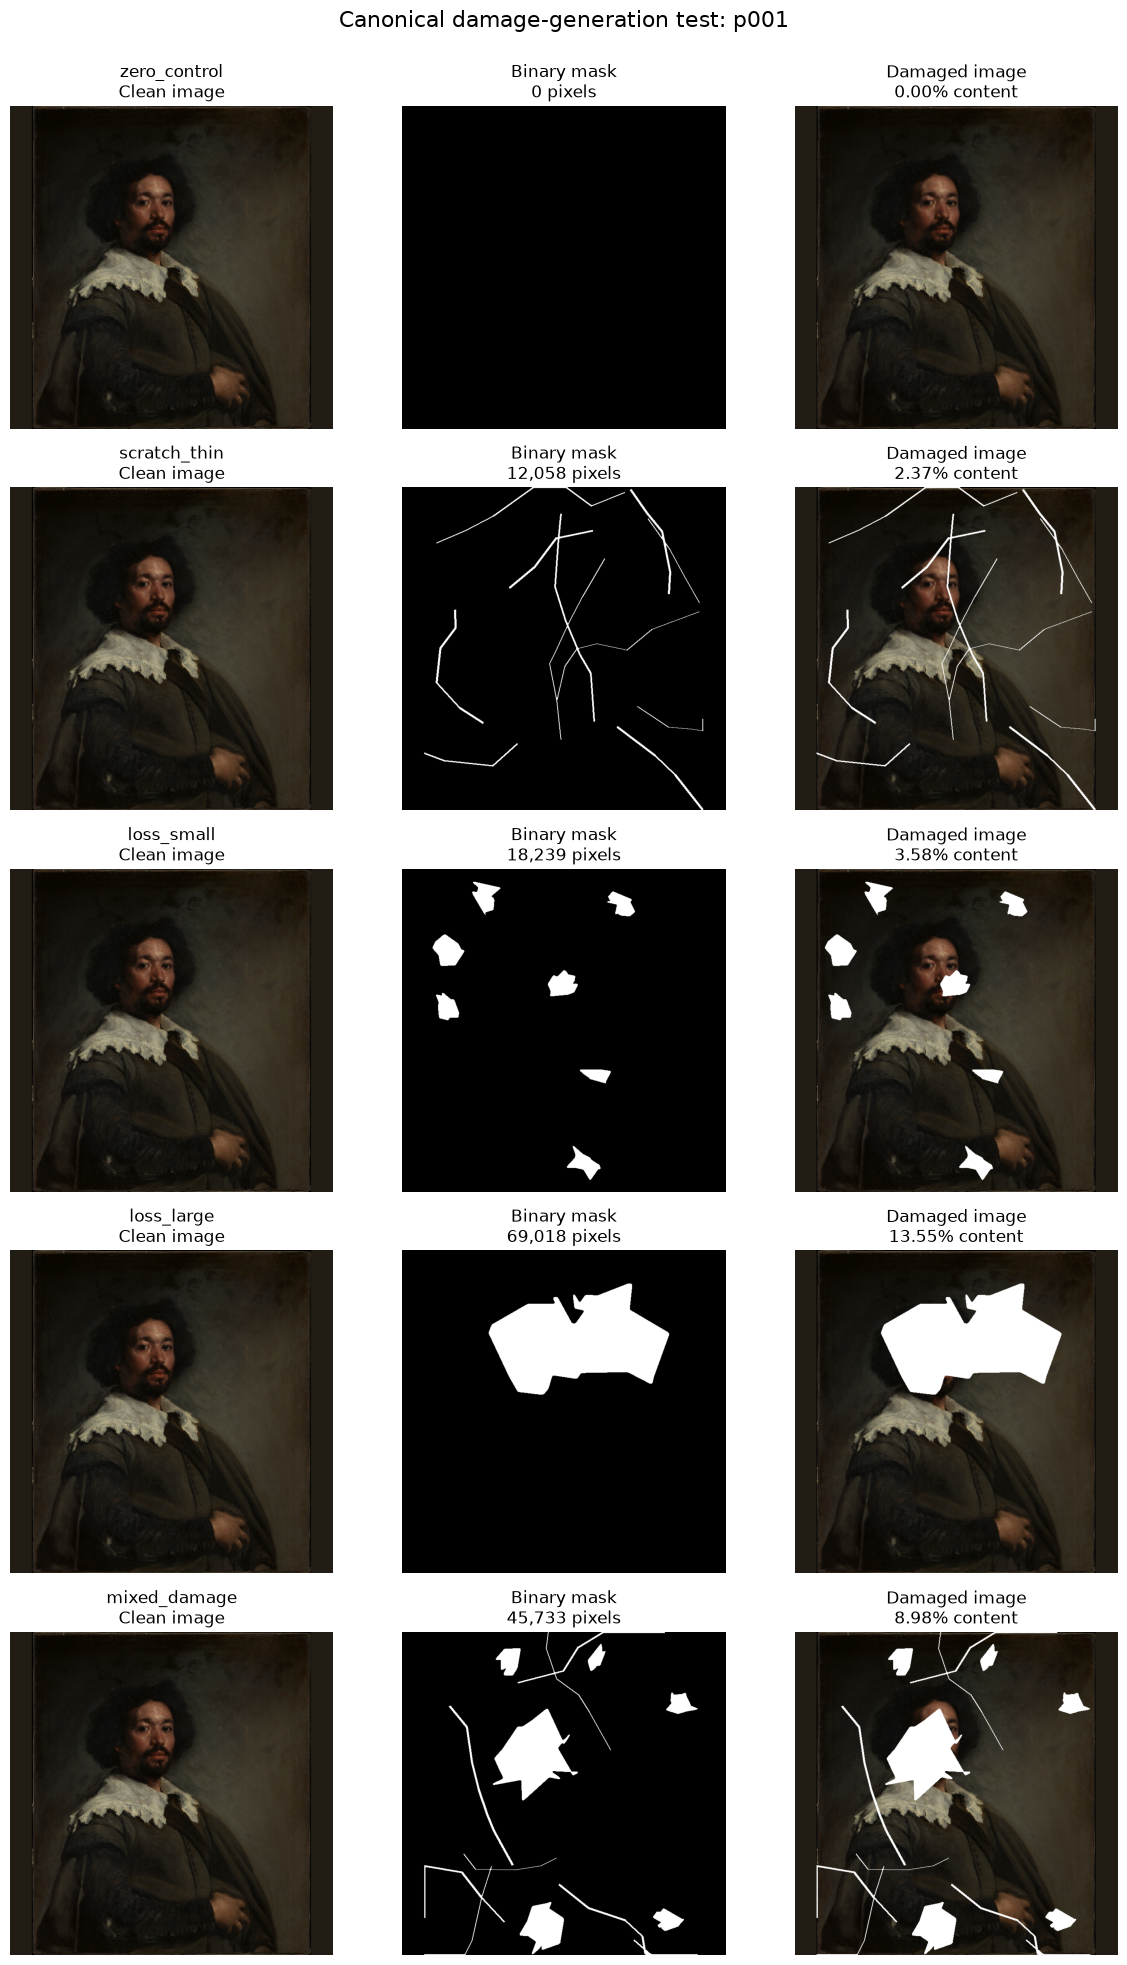

Saved test visualisation: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_creation\one_painting_damage_generation_test.png

Visual-inspection note: white regions represent the configured synthetic damage fill. The binary mask remains the authoritative damage-region definition.


In [5]:
# Visually inspect the one-painting damage-generation test

test_visual_metadata_df = (
    test_damaged_metadata_df
    .copy()
)


test_visual_metadata_df[
    "mask_type"
] = pd.Categorical(
    test_visual_metadata_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


test_visual_metadata_df = (
    test_visual_metadata_df
    .sort_values(
        [
            "mask_type",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


number_of_visual_cases = len(
    test_visual_metadata_df
)


if number_of_visual_cases <= 0:
    raise RuntimeError(
        "No one-painting test cases are "
        "available for visual inspection."
    )


test_figure, test_axes = plt.subplots(
    number_of_visual_cases,
    3,
    figsize=(
        12,
        4 * number_of_visual_cases,
    ),
)


if number_of_visual_cases == 1:
    test_axes = np.expand_dims(
        test_axes,
        axis=0,
    )


for row_index, test_row in (
    test_visual_metadata_df.iterrows()
):
    test_clean_path = Path(
        str(
            test_row[
                "clean_path"
            ]
        )
    )

    test_mask_path = Path(
        str(
            test_row[
                "mask_path"
            ]
        )
    )

    test_damaged_path = Path(
        str(
            test_row[
                "damaged_path"
            ]
        )
    )


    if not test_clean_path.is_absolute():
        test_clean_path = (
            PROJECT_ROOT
            / test_clean_path
        )


    if not test_mask_path.is_absolute():
        test_mask_path = (
            PROJECT_ROOT
            / test_mask_path
        )


    if not test_damaged_path.is_absolute():
        test_damaged_path = (
            PROJECT_ROOT
            / test_damaged_path
        )


    for required_test_path in [
        test_clean_path,
        test_mask_path,
        test_damaged_path,
    ]:
        if not required_test_path.exists():
            raise FileNotFoundError(
                "Test visualisation source "
                f"does not exist: {required_test_path}"
            )


    with Image.open(
        test_clean_path
    ) as opened_clean_image:
        test_clean_array = np.asarray(
            opened_clean_image.convert(
                "RGB"
            )
        )


    with Image.open(
        test_mask_path
    ) as opened_mask_image:
        test_mask_array = np.asarray(
            opened_mask_image.convert(
                "L"
            )
        )


    with Image.open(
        test_damaged_path
    ) as opened_damaged_image:
        test_damaged_array = np.asarray(
            opened_damaged_image.convert(
                "RGB"
            )
        )


    test_axes[
        row_index,
        0,
    ].imshow(
        test_clean_array
    )

    test_axes[
        row_index,
        0,
    ].set_title(
        f"{test_row['mask_type']}\n"
        "Clean image"
    )


    test_axes[
        row_index,
        1,
    ].imshow(
        test_mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    test_axes[
        row_index,
        1,
    ].set_title(
        "Binary mask\n"
        f"{int(test_row['damaged_area_pixels']):,} pixels"
    )


    test_axes[
        row_index,
        2,
    ].imshow(
        test_damaged_array
    )

    test_axes[
        row_index,
        2,
    ].set_title(
        "Damaged image\n"
        f"{float(test_row['damaged_area_percentage_content']):.2f}% content"
    )


    for test_axis in test_axes[
        row_index
    ]:
        test_axis.axis("off")


test_figure.suptitle(
    "Canonical damage-generation test: "
    f"{test_painting_id}",
    fontsize=16,
)


test_figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.98,
    ]
)


test_visualisation_path = (
    damage_figure_dir
    / "one_painting_damage_generation_test.png"
)


test_figure.savefig(
    test_visualisation_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(test_figure)


if not test_visualisation_path.exists():
    raise FileNotFoundError(
        "The one-painting damage-generation "
        "figure was not saved."
    )


if (
    test_visualisation_path
    .stat()
    .st_size
    <= 0
):
    raise RuntimeError(
        "The one-painting damage-generation "
        "figure is empty."
    )


print(
    "Saved test visualisation:",
    test_visualisation_path,
)


print(
    "\nVisual-inspection note: white regions "
    "represent the configured synthetic damage "
    "fill. The binary mask remains the "
    "authoritative damage-region definition."
)

In [6]:
# Generate the full canonical damaged-image dataset

expected_case_ids = (
    mask_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


expected_case_id_set = set(
    expected_case_ids
)


expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}


existing_damaged_files_before_generation = {
    damaged_file_path.name
    for damaged_file_path
    in damaged_image_dir.glob(
        "*_damaged.png"
    )
    if damaged_file_path.is_file()
}


stale_damaged_filenames_before_generation = sorted(
    existing_damaged_files_before_generation
    - expected_damaged_filenames
)


stale_damaged_file_records = [
    {
        "damaged_filename": stale_filename,
        "damaged_path": str(
            damaged_image_dir
            / stale_filename
        ),
    }
    for stale_filename
    in stale_damaged_filenames_before_generation
]


print(
    "Existing damaged files before generation:",
    len(
        existing_damaged_files_before_generation
    ),
)


print(
    "Stale or orphaned damaged files "
    "before generation:",
    len(
        stale_damaged_filenames_before_generation
    ),
)


if stale_damaged_file_records:
    stale_damaged_files_before_generation_df = (
        pd.DataFrame(
            stale_damaged_file_records
        )
    )

    display(
        stale_damaged_files_before_generation_df
        .head(20)
    )


    for stale_filename in (
        stale_damaged_filenames_before_generation
    ):
        stale_damaged_path = (
            damaged_image_dir
            / stale_filename
        )

        stale_damaged_path.unlink()


    print(
        "Removed stale damaged files:",
        len(
            stale_damaged_filenames_before_generation
        ),
    )

else:
    stale_damaged_files_before_generation_df = (
        pd.DataFrame(
            columns=[
                "damaged_filename",
                "damaged_path",
            ]
        )
    )


generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


damaged_metadata_df = (
    create_damaged_images_for_dataset(
        processed_metadata=(
            processed_metadata_df
        ),
        mask_metadata=(
            mask_metadata_df
        ),
        clean_dir=clean_image_dir,
        damaged_dir=damaged_image_dir,
        fill_color=damage_fill_color,
        fill_strategy=damage_fill_strategy,
        project_root=PROJECT_ROOT,
        overwrite=True,
        compute_checksums=True,
    )
)


generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


print(
    "Generated damaged-image metadata rows:",
    len(damaged_metadata_df),
)


print("\nGeneration status")
print("-----------------")

display(
    damaged_metadata_df[
        "status"
    ]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="count")
)


if (
    "generation_action"
    in damaged_metadata_df.columns
):
    print("\nGeneration actions")
    print("------------------")

    display(
        damaged_metadata_df[
            "generation_action"
        ]
        .value_counts(dropna=False)
        .rename_axis(
            "generation_action"
        )
        .reset_index(name="count")
    )


generation_error_rows_df = (
    damaged_metadata_df.loc[
        damaged_metadata_df[
            "status"
        ]
        != "ok"
    ]
    .copy()
)


if not generation_error_rows_df.empty:
    generation_error_display_columns = [
        column_name
        for column_name in [
            "case_id",
            "painting_id",
            "mask_type",
            "damaged_path",
            "status",
            "issue",
        ]
        if column_name
        in generation_error_rows_df.columns
    ]

    display(
        generation_error_rows_df[
            generation_error_display_columns
        ]
    )

    raise RuntimeError(
        "Full damaged-image generation "
        "produced one or more errors."
    )


if (
    len(damaged_metadata_df)
    != expected_case_count
):
    raise RuntimeError(
        "Unexpected damaged-image metadata "
        "row count: "
        f"observed={len(damaged_metadata_df)}, "
        f"expected={expected_case_count}"
    )


duplicate_generated_case_rows = (
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


duplicate_generated_filename_rows = (
    damaged_metadata_df[
        "damaged_filename"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


duplicate_generated_path_rows = (
    damaged_metadata_df[
        "damaged_path"
    ]
    .astype(str)
    .duplicated(
        keep=False
    )
)


if duplicate_generated_case_rows.any():
    duplicate_case_values = (
        damaged_metadata_df.loc[
            duplicate_generated_case_rows,
            "case_id",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Generated damaged metadata contains "
        "duplicate case IDs: "
        f"{duplicate_case_values[:10]}"
    )


if duplicate_generated_filename_rows.any():
    duplicate_filename_values = (
        damaged_metadata_df.loc[
            duplicate_generated_filename_rows,
            "damaged_filename",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Generated damaged metadata contains "
        "duplicate damaged filenames: "
        f"{duplicate_filename_values[:10]}"
    )


if duplicate_generated_path_rows.any():
    duplicate_path_values = (
        damaged_metadata_df.loc[
            duplicate_generated_path_rows,
            "damaged_path",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Generated damaged metadata contains "
        "duplicate damaged-image paths: "
        f"{duplicate_path_values[:10]}"
    )


generated_case_id_set = set(
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
)


missing_generated_case_ids = sorted(
    expected_case_id_set
    - generated_case_id_set
)


unexpected_generated_case_ids = sorted(
    generated_case_id_set
    - expected_case_id_set
)


if missing_generated_case_ids:
    raise RuntimeError(
        "Expected mask cases are missing from "
        "damaged-image metadata: "
        f"{missing_generated_case_ids[:10]}"
    )


if unexpected_generated_case_ids:
    raise RuntimeError(
        "Unexpected damaged-image cases were "
        "generated: "
        f"{unexpected_generated_case_ids[:10]}"
    )


required_generation_metadata_columns = [
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "generation_action",
    "clean_path",
    "mask_path",
    "damaged_path",
    "damage_fill_strategy",
    "damage_fill_r",
    "damage_fill_g",
    "damage_fill_b",
    "width",
    "height",
    "mode",
    "format",
    "damaged_file_size_bytes",
    "clean_sha256",
    "mask_sha256",
    "damaged_sha256",
]


missing_generation_metadata_columns = [
    column_name
    for column_name
    in required_generation_metadata_columns
    if column_name
    not in damaged_metadata_df.columns
]


if missing_generation_metadata_columns:
    raise RuntimeError(
        "Generated damaged metadata is missing "
        "required provenance columns: "
        f"{missing_generation_metadata_columns}"
    )


null_provenance_counts = (
    damaged_metadata_df[
        required_generation_metadata_columns
    ]
    .isna()
    .sum()
)


invalid_null_provenance_df = (
    null_provenance_counts.loc[
        null_provenance_counts > 0
    ]
    .rename("null_count")
    .reset_index()
    .rename(
        columns={
            "index": "column",
        }
    )
)


if not invalid_null_provenance_df.empty:
    display(
        invalid_null_provenance_df
    )

    raise RuntimeError(
        "Generated damaged metadata contains "
        "missing provenance values."
    )


generated_damage_fill_strategies = set(
    damaged_metadata_df[
        "damage_fill_strategy"
    ]
    .dropna()
    .astype(str)
)


if generated_damage_fill_strategies != {
    damage_fill_strategy
}:
    raise RuntimeError(
        "Generated metadata contains an "
        "unexpected damage-fill strategy: "
        f"{sorted(generated_damage_fill_strategies)}"
    )


generated_damage_fill_colors = (
    damaged_metadata_df[
        [
            "damage_fill_r",
            "damage_fill_g",
            "damage_fill_b",
        ]
    ]
    .drop_duplicates()
    .astype(int)
)


if len(
    generated_damage_fill_colors
) != 1:
    raise RuntimeError(
        "Generated metadata contains more than "
        "one damage-fill colour."
    )


observed_damage_fill_color = tuple(
    generated_damage_fill_colors
    .iloc[0]
    .tolist()
)


if (
    observed_damage_fill_color
    != damage_fill_color
):
    raise RuntimeError(
        "Generated metadata damage-fill colour "
        "does not match the configured value: "
        f"observed={observed_damage_fill_color}, "
        f"expected={damage_fill_color}"
    )


print(
    "\nFull canonical damaged-image "
    "generation passed."
)

Existing damaged files before generation: 0
Stale or orphaned damaged files before generation: 0
Generated damaged-image metadata rows: 250

Generation status
-----------------


,status,count
0,ok,250



Generation actions
------------------


,generation_action,count
0,generated,250



Full canonical damaged-image generation passed.


In [7]:
# Finalize, save, and reload canonical damaged-image metadata

required_canonical_metadata_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "clean_filename",
    "clean_path",
    "mask_filename",
    "mask_path",
    "damaged_filename",
    "damaged_path",
    "damage_fill_strategy",
    "damage_fill_r",
    "damage_fill_g",
    "damage_fill_b",
    "damaged_area_pixels",
    "damaged_area_percentage_content",
    "damaged_area_percentage_full",
    "status",
    "issue",
]


missing_canonical_metadata_columns = [
    column_name
    for column_name in required_canonical_metadata_columns
    if column_name not in damaged_metadata_df.columns
]


if missing_canonical_metadata_columns:
    raise RuntimeError(
        "Damaged-image metadata is missing required "
        "canonical columns: "
        f"{missing_canonical_metadata_columns}"
    )


canonical_damaged_metadata_df = (
    damaged_metadata_df.copy()
)


canonical_damaged_metadata_df[
    "config_version"
] = config_version

canonical_damaged_metadata_df[
    "experiment_name"
] = experiment_name

canonical_damaged_metadata_df[
    "experiment_version"
] = experiment_version

canonical_damaged_metadata_df[
    "notebook_stage"
] = "04_damage_creation"


canonical_damaged_metadata_df[
    "mask_type"
] = pd.Categorical(
    canonical_damaged_metadata_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


canonical_damaged_metadata_df = (
    canonical_damaged_metadata_df
    .sort_values(
        [
            "painting_id",
            "mask_type",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


canonical_damaged_metadata_df[
    "mask_type"
] = (
    canonical_damaged_metadata_df[
        "mask_type"
    ]
    .astype("object")
    .astype(str)
)


if (
    len(canonical_damaged_metadata_df)
    != expected_case_count
):
    raise RuntimeError(
        "Canonical damaged metadata row count "
        "does not match the expected case count."
    )


if canonical_damaged_metadata_df[
    "case_id"
].astype(str).duplicated().any():
    raise RuntimeError(
        "Canonical damaged metadata contains "
        "duplicate case IDs."
    )


if canonical_damaged_metadata_df[
    "damaged_filename"
].astype(str).duplicated().any():
    raise RuntimeError(
        "Canonical damaged metadata contains "
        "duplicate damaged filenames."
    )


if canonical_damaged_metadata_df[
    "damaged_path"
].astype(str).duplicated().any():
    raise RuntimeError(
        "Canonical damaged metadata contains "
        "duplicate damaged-image paths."
    )


if canonical_damaged_metadata_df[
    "status"
].astype(str).ne("ok").any():
    failed_canonical_rows_df = (
        canonical_damaged_metadata_df.loc[
            canonical_damaged_metadata_df[
                "status"
            ].astype(str)
            != "ok"
        ]
        .copy()
    )

    display(failed_canonical_rows_df)

    raise RuntimeError(
        "Canonical damaged metadata contains "
        "unsuccessful generation rows."
    )


temporary_damaged_metadata_path = (
    damaged_metadata_path.with_suffix(
        ".tmp.csv"
    )
)


canonical_damaged_metadata_df.to_csv(
    temporary_damaged_metadata_path,
    index=False,
)


if not temporary_damaged_metadata_path.exists():
    raise FileNotFoundError(
        "Temporary damaged metadata file "
        "was not created."
    )


if (
    temporary_damaged_metadata_path
    .stat()
    .st_size
    <= 0
):
    raise RuntimeError(
        "Temporary damaged metadata file "
        "is empty."
    )


temporary_damaged_metadata_path.replace(
    damaged_metadata_path
)


reloaded_damaged_metadata_df = pd.read_csv(
    damaged_metadata_path
)


print("Canonical damaged metadata saved")
print("--------------------------------")
print("Path:", damaged_metadata_path)
print(
    "Rows:",
    len(reloaded_damaged_metadata_df),
)
print(
    "Columns:",
    len(reloaded_damaged_metadata_df.columns),
)


if (
    len(reloaded_damaged_metadata_df)
    != len(canonical_damaged_metadata_df)
):
    raise RuntimeError(
        "Reloaded damaged metadata row count "
        "does not match the saved DataFrame."
    )


if (
    list(reloaded_damaged_metadata_df.columns)
    != list(canonical_damaged_metadata_df.columns)
):
    raise RuntimeError(
        "Reloaded damaged metadata columns do "
        "not match the saved DataFrame."
    )


saved_case_ids = (
    canonical_damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


reloaded_case_ids = (
    reloaded_damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


if reloaded_case_ids != saved_case_ids:
    raise RuntimeError(
        "Reloaded damaged metadata case ordering "
        "does not match the saved canonical order."
    )


exact_reload_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "clean_filename",
    "clean_path",
    "mask_filename",
    "mask_path",
    "damaged_filename",
    "damaged_path",
    "damage_fill_strategy",
    "damage_fill_r",
    "damage_fill_g",
    "damage_fill_b",
    "damaged_area_pixels",
    "status",
    "config_version",
    "experiment_name",
    "experiment_version",
    "notebook_stage",
]


available_exact_reload_columns = [
    column_name
    for column_name in exact_reload_columns
    if column_name
    in canonical_damaged_metadata_df.columns
]


reload_comparison_records = []


for column_name in available_exact_reload_columns:
    original_series = (
        canonical_damaged_metadata_df[
            column_name
        ]
        .fillna("")
        .astype(str)
    )

    reloaded_series = (
        reloaded_damaged_metadata_df[
            column_name
        ]
        .fillna("")
        .astype(str)
    )

    reload_comparison_records.append(
        {
            "column": column_name,
            "comparison": "exact_string",
            "passed": bool(
                original_series.equals(
                    reloaded_series
                )
            ),
        }
    )


float_reload_columns = [
    "damaged_area_percentage_content",
    "damaged_area_percentage_full",
]


for column_name in float_reload_columns:
    if (
        column_name
        not in canonical_damaged_metadata_df.columns
    ):
        continue

    original_values = pd.to_numeric(
        canonical_damaged_metadata_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    reloaded_values = pd.to_numeric(
        reloaded_damaged_metadata_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy(
        dtype=float
    )

    reload_comparison_records.append(
        {
            "column": column_name,
            "comparison": "numeric_isclose",
            "passed": bool(
                np.allclose(
                    original_values,
                    reloaded_values,
                    rtol=0.0,
                    atol=1e-10,
                    equal_nan=True,
                )
            ),
        }
    )


metadata_reload_validation_df = pd.DataFrame(
    reload_comparison_records
)


display(
    metadata_reload_validation_df
)


failed_reload_columns_df = (
    metadata_reload_validation_df.loc[
        ~metadata_reload_validation_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_reload_columns_df.empty:
    display(
        failed_reload_columns_df
    )

    raise RuntimeError(
        "Canonical damaged metadata did not "
        "survive save-and-reload verification."
    )


damaged_metadata_df = (
    reloaded_damaged_metadata_df.copy()
)


print(
    "\nCanonical damaged metadata save "
    "and reload verification passed."
)

Canonical damaged metadata saved
--------------------------------
Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damaged_images.csv
Rows: 250
Columns: 35


,column,comparison,passed
0,case_id,exact_string,True
1,painting_id,exact_string,True
2,mask_id,exact_string,True
3,mask_type,exact_string,True
4,clean_filename,exact_string,True
5,clean_path,exact_string,True
6,mask_filename,exact_string,True
7,mask_path,exact_string,True
8,damaged_filename,exact_string,True
9,damaged_path,exact_string,True



Canonical damaged metadata save and reload verification passed.


In [8]:
# Validate all canonical damaged images after metadata reload

damaged_file_validation_df = (
    validate_damaged_images(
        damaged_metadata=damaged_metadata_df,
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)


damage_application_validation_df = (
    validate_damage_application(
        damaged_metadata=damaged_metadata_df,
        target_size=target_size,
        project_root=PROJECT_ROOT,
        verify_source_checksums=True,
    )
)


print("Saved damaged-image validation")
print("--------------------------------")

display(
    damaged_file_validation_df.head()
)


print("\nDamage-application validation")
print("-----------------------------")

display(
    damage_application_validation_df.head()
)


required_file_validation_columns = [
    "case_id",
    "file_exists",
    "readable",
    "validation_passed",
]


missing_file_validation_columns = [
    column_name
    for column_name
    in required_file_validation_columns
    if column_name
    not in damaged_file_validation_df.columns
]


if missing_file_validation_columns:
    raise RuntimeError(
        "Saved-file validation output is missing "
        "required columns: "
        f"{missing_file_validation_columns}"
    )


required_application_validation_columns = [
    "case_id",
    "validation_passed",
]


missing_application_validation_columns = [
    column_name
    for column_name
    in required_application_validation_columns
    if column_name
    not in damage_application_validation_df.columns
]


if missing_application_validation_columns:
    raise RuntimeError(
        "Damage-application validation output "
        "is missing required columns: "
        f"{missing_application_validation_columns}"
    )


if (
    len(damaged_file_validation_df)
    != expected_case_count
):
    raise RuntimeError(
        "Saved-file validation row count does "
        "not match the expected case count."
    )


if (
    len(damage_application_validation_df)
    != expected_case_count
):
    raise RuntimeError(
        "Damage-application validation row count "
        "does not match the expected case count."
    )


if damaged_file_validation_df[
    "case_id"
].astype(str).duplicated().any():
    raise RuntimeError(
        "Saved-file validation contains "
        "duplicate case IDs."
    )


if damage_application_validation_df[
    "case_id"
].astype(str).duplicated().any():
    raise RuntimeError(
        "Damage-application validation contains "
        "duplicate case IDs."
    )


expected_validation_case_ids = set(
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
)


file_validation_case_ids = set(
    damaged_file_validation_df[
        "case_id"
    ]
    .astype(str)
)


application_validation_case_ids = set(
    damage_application_validation_df[
        "case_id"
    ]
    .astype(str)
)


if (
    file_validation_case_ids
    != expected_validation_case_ids
):
    raise RuntimeError(
        "Saved-file validation case coverage "
        "does not match canonical metadata."
    )


if (
    application_validation_case_ids
    != expected_validation_case_ids
):
    raise RuntimeError(
        "Damage-application validation case "
        "coverage does not match canonical metadata."
    )


file_validation_issue_column = next(
    (
        column_name
        for column_name in [
            "issue",
            "validation_issue",
        ]
        if column_name
        in damaged_file_validation_df.columns
    ),
    None,
)


application_validation_issue_column = next(
    (
        column_name
        for column_name in [
            "issue",
            "validation_issue",
        ]
        if column_name
        in damage_application_validation_df.columns
    ),
    None,
)


if file_validation_issue_column is not None:
    print("\nSaved-file validation issues")
    print("----------------------------")

    display(
        damaged_file_validation_df[
            file_validation_issue_column
        ]
        .fillna("")
        .replace("", "ok")
        .value_counts(dropna=False)
        .rename_axis("issue")
        .reset_index(name="count")
    )


if application_validation_issue_column is not None:
    print("\nApplication-validation issues")
    print("-----------------------------")

    display(
        damage_application_validation_df[
            application_validation_issue_column
        ]
        .fillna("")
        .replace("", "ok")
        .value_counts(dropna=False)
        .rename_axis("issue")
        .reset_index(name="count")
    )


failed_damaged_file_validation_df = (
    damaged_file_validation_df.loc[
        ~damaged_file_validation_df[
            "validation_passed"
        ].astype(bool)
    ]
    .copy()
)


failed_damage_application_validation_df = (
    damage_application_validation_df.loc[
        ~damage_application_validation_df[
            "validation_passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_damaged_file_validation_df.empty:
    display(
        failed_damaged_file_validation_df
    )

    raise RuntimeError(
        "One or more saved damaged images failed "
        "file validation after reload."
    )


if not failed_damage_application_validation_df.empty:
    display(
        failed_damage_application_validation_df
    )

    raise RuntimeError(
        "One or more damaged images failed "
        "pixel-level application validation."
    )


print(
    "\nAll canonical damaged images passed "
    "saved-file and application validation."
)

Saved damaged-image validation
--------------------------------


,case_id,painting_id,mask_type,damaged_path,file_exists,readable,width,height,mode,format,file_size_bytes,filename_matches_metadata,calculated_damaged_sha256,issue_count,validation_passed,issue
0,p001_zero_control,p001,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,723881,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0,True,
1,p001_scratch_thin,p001,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,728164,True,7d2e0affa9d97493f34263767ed46cce8d5df73a74caa2...,0,True,
2,p001_loss_small,p001,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,704339,True,d8cb0269b9074b0e596d3ef817ab3c98ec1838b06457dd...,0,True,
3,p001_loss_large,p001,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,631126,True,b7d7bd4dc2c427bc58c96a397bb24defe2f34945ad8114...,0,True,
4,p001_mixed_damage,p001,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,768,768,RGB,PNG,675436,True,e5a985ef19e47ab186d825692ca24efbea810c3bd1391a...,0,True,



Damage-application validation
-----------------------------


,case_id,painting_id,mask_type,outside_mask_changed_pixels,inside_mask_not_fill_pixels,total_mask_pixels,metadata_mask_pixels,mask_pixel_count_difference,changed_pixel_count,unchanged_mask_pixel_count,expected_changeable_mask_pixels,changed_pixel_count_difference,clean_equals_damaged,outside_preservation_valid,fill_application_valid,calculated_clean_sha256,calculated_mask_sha256,issue_count,validation_passed,issue
0,p001_zero_control,p001,zero_control,0,0,0,0,0,0,0,0,0,True,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,49e2b0f2e0dc8fe44017bdabfa19ff50311b0bdd176233...,0,True,
1,p001_scratch_thin,p001,scratch_thin,0,0,12058,12058,0,12058,0,12058,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,14dc08421a7e8d5a5f8f96825a2161b6295cd41a98e48a...,0,True,
2,p001_loss_small,p001,loss_small,0,0,18239,18239,0,18239,0,18239,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,3b1600dab63bd0ee34f019c51e988b02bb43cb193d8930...,0,True,
3,p001_loss_large,p001,loss_large,0,0,69018,69018,0,69018,0,69018,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,0c3aa0f9d930a7b8405439b8ec04e899f72bbe219472b0...,0,True,
4,p001_mixed_damage,p001,mixed_damage,0,0,45733,45733,0,45733,0,45733,0,False,True,True,b5852f0337c8342a1a70268f9e9f682534177581d23871...,66aa435e3d05dd8f922f95a0065ef7b626192d8a1e9833...,0,True,



Saved-file validation issues
----------------------------


,issue,count
0,ok,250



Application-validation issues
-----------------------------


,issue,count
0,ok,250



All canonical damaged images passed saved-file and application validation.


In [10]:
# Build the canonical damage-creation inventory audit

expected_damaged_filename_set = set(
    damaged_metadata_df[
        "damaged_filename"
    ]
    .astype(str)
)


actual_damaged_file_paths = sorted(
    damaged_image_dir.glob(
        "*_damaged.png"
    )
)


actual_damaged_filename_set = {
    damaged_file_path.name
    for damaged_file_path
    in actual_damaged_file_paths
    if damaged_file_path.is_file()
}


missing_damaged_filenames = sorted(
    expected_damaged_filename_set
    - actual_damaged_filename_set
)


orphaned_damaged_filenames = sorted(
    actual_damaged_filename_set
    - expected_damaged_filename_set
)


non_png_files_in_damaged_dir = sorted(
    file_path.name
    for file_path in damaged_image_dir.iterdir()
    if (
        file_path.is_file()
        and file_path.suffix.lower() != ".png"
    )
)


zero_byte_damaged_files = sorted(
    damaged_file_path.name
    for damaged_file_path
    in actual_damaged_file_paths
    if (
        damaged_file_path.is_file()
        and damaged_file_path.stat().st_size <= 0
    )
)


damaged_metadata_case_ids = (
    damaged_metadata_df[
        "case_id"
    ]
    .astype(str)
)


damaged_metadata_mask_ids = (
    damaged_metadata_df[
        "mask_id"
    ]
    .astype(str)
)


damaged_metadata_filenames = (
    damaged_metadata_df[
        "damaged_filename"
    ]
    .astype(str)
)


damaged_metadata_paths = (
    damaged_metadata_df[
        "damaged_path"
    ]
    .astype(str)
)


observed_damaged_mask_type_counts = (
    damaged_metadata_df[
        "mask_type"
    ]
    .astype(str)
    .value_counts()
    .reindex(
        configured_mask_types,
        fill_value=0,
    )
)


invalid_damaged_mask_type_counts = (
    observed_damaged_mask_type_counts.loc[
        observed_damaged_mask_type_counts
        != expected_painting_count
    ]
)


checksum_columns = [
    column_name
    for column_name in [
        "clean_sha256",
        "mask_sha256",
        "damaged_sha256",
    ]
    if column_name
    in damaged_metadata_df.columns
]


missing_checksum_value_count = int(
    damaged_metadata_df[
        checksum_columns
    ]
    .isna()
    .sum()
    .sum()
) if checksum_columns else 0


empty_checksum_value_count = int(
    damaged_metadata_df[
        checksum_columns
    ]
    .fillna("")
    .astype(str)
    .apply(
        lambda column_series: (
            column_series.str.strip() == ""
        )
    )
    .sum()
    .sum()
) if checksum_columns else 0


invalid_checksum_length_count = 0


for checksum_column in checksum_columns:
    checksum_series = (
        damaged_metadata_df[
            checksum_column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    non_empty_checksum_series = (
        checksum_series.loc[
            checksum_series.ne("")
        ]
    )

    invalid_checksum_length_count += int(
        non_empty_checksum_series
        .str.len()
        .ne(64)
        .sum()
    )


metadata_status_failure_count = int(
    damaged_metadata_df[
        "status"
    ]
    .astype(str)
    .ne("ok")
    .sum()
)


saved_file_validation_failure_count = int(
    (
        ~damaged_file_validation_df[
            "validation_passed"
        ].astype(bool)
    ).sum()
)


application_validation_failure_count = int(
    (
        ~damage_application_validation_df[
            "validation_passed"
        ].astype(bool)
    ).sum()
)


damage_creation_audit_records = [
    {
        "audit_section": "input",
        "check": "processed_painting_count",
        "observed": len(
            processed_metadata_df
        ),
        "expected": expected_painting_count,
        "passed": (
            len(processed_metadata_df)
            == expected_painting_count
        ),
        "details": "",
    },
    {
        "audit_section": "input",
        "check": "canonical_mask_case_count",
        "observed": len(
            mask_metadata_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(mask_metadata_df)
            == expected_case_count
        ),
        "details": "",
    },
    {
        "audit_section": "generation",
        "check": "damaged_metadata_row_count",
        "observed": len(
            damaged_metadata_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(damaged_metadata_df)
            == expected_case_count
        ),
        "details": "",
    },
    {
        "audit_section": "generation",
        "check": "damaged_png_file_count",
        "observed": len(
            actual_damaged_filename_set
        ),
        "expected": expected_case_count,
        "passed": (
            len(actual_damaged_filename_set)
            == expected_case_count
        ),
        "details": "",
    },
    {
        "audit_section": "uniqueness",
        "check": "duplicate_case_ids",
        "observed": int(
            damaged_metadata_case_ids
            .duplicated()
            .sum()
        ),
        "expected": 0,
        "passed": bool(
            not damaged_metadata_case_ids
            .duplicated()
            .any()
        ),
        "details": "",
    },
    {
        "audit_section": "uniqueness",
        "check": "duplicate_mask_ids",
        "observed": int(
            damaged_metadata_mask_ids
            .duplicated()
            .sum()
        ),
        "expected": 0,
        "passed": bool(
            not damaged_metadata_mask_ids
            .duplicated()
            .any()
        ),
        "details": "",
    },
    {
        "audit_section": "uniqueness",
        "check": "duplicate_damaged_filenames",
        "observed": int(
            damaged_metadata_filenames
            .duplicated()
            .sum()
        ),
        "expected": 0,
        "passed": bool(
            not damaged_metadata_filenames
            .duplicated()
            .any()
        ),
        "details": "",
    },
    {
        "audit_section": "uniqueness",
        "check": "duplicate_damaged_paths",
        "observed": int(
            damaged_metadata_paths
            .duplicated()
            .sum()
        ),
        "expected": 0,
        "passed": bool(
            not damaged_metadata_paths
            .duplicated()
            .any()
        ),
        "details": "",
    },
    {
        "audit_section": "coverage",
        "check": "invalid_cases_per_mask_type",
        "observed": len(
            invalid_damaged_mask_type_counts
        ),
        "expected": 0,
        "passed": (
            invalid_damaged_mask_type_counts.empty
        ),
        "details": (
            "; ".join(
                f"{mask_type}={int(case_count)}"
                for mask_type, case_count
                in invalid_damaged_mask_type_counts.items()
            )
        ),
    },
    {
        "audit_section": "inventory",
        "check": "missing_damaged_files",
        "observed": len(
            missing_damaged_filenames
        ),
        "expected": 0,
        "passed": (
            not missing_damaged_filenames
        ),
        "details": "; ".join(
            missing_damaged_filenames[:20]
        ),
    },
    {
        "audit_section": "inventory",
        "check": "orphaned_damaged_files",
        "observed": len(
            orphaned_damaged_filenames
        ),
        "expected": 0,
        "passed": (
            not orphaned_damaged_filenames
        ),
        "details": "; ".join(
            orphaned_damaged_filenames[:20]
        ),
    },
    {
        "audit_section": "inventory",
        "check": (
            "stale_files_removed_before_generation"
        ),
        "observed": len(
            stale_damaged_filenames_before_generation
        ),
        "expected": (
            "informational"
        ),
        "passed": True,
        "details": "; ".join(
            stale_damaged_filenames_before_generation[
                :20
            ]
        ),
    },
    {
        "audit_section": "inventory",
        "check": "non_png_files_in_damaged_dir",
        "observed": len(
            non_png_files_in_damaged_dir
        ),
        "expected": 0,
        "passed": (
            not non_png_files_in_damaged_dir
        ),
        "details": "; ".join(
            non_png_files_in_damaged_dir[:20]
        ),
    },
    {
        "audit_section": "inventory",
        "check": "zero_byte_damaged_files",
        "observed": len(
            zero_byte_damaged_files
        ),
        "expected": 0,
        "passed": (
            not zero_byte_damaged_files
        ),
        "details": "; ".join(
            zero_byte_damaged_files[:20]
        ),
    },
    {
        "audit_section": "metadata",
        "check": "generation_status_failures",
        "observed": metadata_status_failure_count,
        "expected": 0,
        "passed": (
            metadata_status_failure_count == 0
        ),
        "details": "",
    },
    {
        "audit_section": "metadata",
        "check": "missing_checksum_values",
        "observed": (
            missing_checksum_value_count
            + empty_checksum_value_count
        ),
        "expected": 0,
        "passed": (
            bool(checksum_columns)
            and missing_checksum_value_count == 0
            and empty_checksum_value_count == 0
        ),
        "details": (
            "Columns: "
            + ", ".join(checksum_columns)
        ),
    },
    {
        "audit_section": "metadata",
        "check": "invalid_checksum_lengths",
        "observed": (
            invalid_checksum_length_count
        ),
        "expected": 0,
        "passed": (
            invalid_checksum_length_count == 0
        ),
        "details": "",
    },
    {
        "audit_section": "validation",
        "check": (
            "saved_file_validation_failures"
        ),
        "observed": (
            saved_file_validation_failure_count
        ),
        "expected": 0,
        "passed": (
            saved_file_validation_failure_count
            == 0
        ),
        "details": "",
    },
    {
        "audit_section": "validation",
        "check": (
            "damage_application_validation_failures"
        ),
        "observed": (
            application_validation_failure_count
        ),
        "expected": 0,
        "passed": (
            application_validation_failure_count
            == 0
        ),
        "details": "",
    },
    {
        "audit_section": "artifact",
        "check": "canonical_metadata_exists",
        "observed": int(
            damaged_metadata_path.exists()
        ),
        "expected": 1,
        "passed": (
            damaged_metadata_path.exists()
            and damaged_metadata_path
            .stat()
            .st_size > 0
        ),
        "details": str(
            damaged_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
    },
]


damage_creation_audit_df = pd.DataFrame(
    damage_creation_audit_records
)


damage_creation_audit_df[
    "passed"
] = (
    damage_creation_audit_df[
        "passed"
    ]
    .astype(bool)
)


damage_creation_audit_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


damage_creation_audit_df.to_csv(
    damage_creation_audit_path,
    index=False,
)


print("Canonical damage-creation audit")
print("--------------------------------")

display(
    damage_creation_audit_df
)


print("\nDamaged cases by mask type")
print("--------------------------")

display(
    observed_damaged_mask_type_counts
    .rename_axis("mask_type")
    .reset_index(name="case_count")
)


failed_damage_audit_df = (
    damage_creation_audit_df.loc[
        ~damage_creation_audit_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_damage_audit_df.empty:
    display(
        failed_damage_audit_df
    )

    raise RuntimeError(
        "Canonical damage-creation inventory "
        "audit failed."
    )


if not damage_creation_audit_path.exists():
    raise FileNotFoundError(
        "Canonical damage-creation audit CSV "
        "was not created."
    )


if (
    damage_creation_audit_path
    .stat()
    .st_size
    <= 0
):
    raise RuntimeError(
        "Canonical damage-creation audit CSV "
        "is empty."
    )


print(
    "\nCanonical damage-creation audit passed."
)

print(
    "Saved the single permanent audit CSV:",
    damage_creation_audit_path,
)

Canonical damage-creation audit
--------------------------------


,audit_section,check,observed,expected,passed,details
0,input,processed_painting_count,50,50,True,
1,input,canonical_mask_case_count,250,250,True,
2,generation,damaged_metadata_row_count,250,250,True,
3,generation,damaged_png_file_count,250,250,True,
4,uniqueness,duplicate_case_ids,0,0,True,
5,uniqueness,duplicate_mask_ids,0,0,True,
6,uniqueness,duplicate_damaged_filenames,0,0,True,
7,uniqueness,duplicate_damaged_paths,0,0,True,
8,coverage,invalid_cases_per_mask_type,0,0,True,
9,inventory,missing_damaged_files,0,0,True,



Damaged cases by mask type
--------------------------


,mask_type,case_count
0,zero_control,50
1,scratch_thin,50
2,loss_small,50
3,loss_large,50
4,mixed_damage,50



Canonical damage-creation audit passed.
Saved the single permanent audit CSV: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\04_damage_creation\damage_creation_audit.csv


In [11]:
# Build canonical damage-generation summary tables

damage_summary_source_df = (
    damaged_metadata_df.copy()
)


damage_summary_source_df[
    "mask_type"
] = pd.Categorical(
    damage_summary_source_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


damage_case_summary_df = (
    damage_summary_source_df
    .groupby(
        "mask_type",
        observed=False,
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        total_damaged_pixels=(
            "damaged_area_pixels",
            "sum",
        ),
        mean_damaged_pixels=(
            "damaged_area_pixels",
            "mean",
        ),
        median_damaged_pixels=(
            "damaged_area_pixels",
            "median",
        ),
        minimum_damaged_pixels=(
            "damaged_area_pixels",
            "min",
        ),
        maximum_damaged_pixels=(
            "damaged_area_pixels",
            "max",
        ),
        mean_damage_percentage_content=(
            "damaged_area_percentage_content",
            "mean",
        ),
        median_damage_percentage_content=(
            "damaged_area_percentage_content",
            "median",
        ),
        mean_damage_percentage_full=(
            "damaged_area_percentage_full",
            "mean",
        ),
        mean_file_size_bytes=(
            "damaged_file_size_bytes",
            "mean",
        ),
        total_file_size_bytes=(
            "damaged_file_size_bytes",
            "sum",
        ),
    )
    .reset_index()
)


numeric_summary_columns = [
    "mean_damaged_pixels",
    "median_damaged_pixels",
    "mean_damage_percentage_content",
    "median_damage_percentage_content",
    "mean_damage_percentage_full",
    "mean_file_size_bytes",
]


for column_name in numeric_summary_columns:
    damage_case_summary_df[
        column_name
    ] = (
        pd.to_numeric(
            damage_case_summary_df[
                column_name
            ],
            errors="coerce",
        )
        .round(4)
    )


required_pixel_validation_columns = [
    "case_id",
    "painting_id",
    "mask_type",
    "total_mask_pixels",
    "changed_pixel_count",
    "unchanged_mask_pixel_count",
    "outside_mask_changed_pixels",
    "inside_mask_not_fill_pixels",
]


missing_pixel_validation_columns = [
    column_name
    for column_name
    in required_pixel_validation_columns
    if column_name
    not in damage_application_validation_df.columns
]


if missing_pixel_validation_columns:
    raise RuntimeError(
        "Damage-application validation is missing "
        "columns required for summary generation: "
        f"{missing_pixel_validation_columns}"
    )


pixel_change_summary_source_df = (
    damage_application_validation_df.copy()
)


pixel_change_summary_source_df[
    "mask_type"
] = pd.Categorical(
    pixel_change_summary_source_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


pixel_change_summary_df = (
    pixel_change_summary_source_df
    .groupby(
        "mask_type",
        observed=False,
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        total_mask_pixels=(
            "total_mask_pixels",
            "sum",
        ),
        total_changed_pixels=(
            "changed_pixel_count",
            "sum",
        ),
        total_unchanged_mask_pixels=(
            "unchanged_mask_pixel_count",
            "sum",
        ),
        total_outside_mask_changes=(
            "outside_mask_changed_pixels",
            "sum",
        ),
        total_inside_mask_fill_failures=(
            "inside_mask_not_fill_pixels",
            "sum",
        ),
        mean_changed_pixels=(
            "changed_pixel_count",
            "mean",
        ),
        mean_unchanged_mask_pixels=(
            "unchanged_mask_pixel_count",
            "mean",
        ),
    )
    .reset_index()
)


pixel_change_summary_df[
    "observed_change_rate_within_mask"
] = np.where(
    pixel_change_summary_df[
        "total_mask_pixels"
    ]
    > 0,
    (
        pixel_change_summary_df[
            "total_changed_pixels"
        ]
        /
        pixel_change_summary_df[
            "total_mask_pixels"
        ]
    ),
    0.0,
)


for column_name in [
    "mean_changed_pixels",
    "mean_unchanged_mask_pixels",
    "observed_change_rate_within_mask",
]:
    pixel_change_summary_df[
        column_name
    ] = (
        pd.to_numeric(
            pixel_change_summary_df[
                column_name
            ],
            errors="coerce",
        )
        .round(6)
    )


generation_provenance_summary_df = pd.DataFrame(
    [
        {
            "field": "config_version",
            "value": config_version,
        },
        {
            "field": "experiment_name",
            "value": experiment_name,
        },
        {
            "field": "experiment_version",
            "value": experiment_version,
        },
        {
            "field": "generator_name",
            "value": damage_generator_name,
        },
        {
            "field": "generator_version",
            "value": damage_generator_version,
        },
        {
            "field": "generation_started_at_utc",
            "value": generation_started_at_utc,
        },
        {
            "field": "generation_completed_at_utc",
            "value": generation_completed_at_utc,
        },
        {
            "field": "fill_strategy",
            "value": damage_fill_strategy,
        },
        {
            "field": "fill_color_rgb",
            "value": str(
                damage_fill_color
            ),
        },
        {
            "field": "target_size",
            "value": str(
                target_size
            ),
        },
        {
            "field": "painting_count",
            "value": str(
                damaged_metadata_df[
                    "painting_id"
                ].nunique()
            ),
        },
        {
            "field": "damage_case_count",
            "value": str(
                len(damaged_metadata_df)
            ),
        },
        {
            "field": "damaged_file_count",
            "value": str(
                len(
                    actual_damaged_filename_set
                )
            ),
        },
        {
            "field": "stale_files_removed",
            "value": str(
                len(
                    stale_damaged_filenames_before_generation
                )
            ),
        },
    ]
)


summary_validation_records = [
    {
        "check": "summary_mask_type_rows",
        "observed": len(
            damage_case_summary_df
        ),
        "expected": expected_mask_type_count,
        "passed": (
            len(damage_case_summary_df)
            == expected_mask_type_count
        ),
    },
    {
        "check": "summary_total_cases",
        "observed": int(
            damage_case_summary_df[
                "case_count"
            ].sum()
        ),
        "expected": expected_case_count,
        "passed": (
            damage_case_summary_df[
                "case_count"
            ].sum()
            == expected_case_count
        ),
    },
    {
        "check": "pixel_summary_total_cases",
        "observed": int(
            pixel_change_summary_df[
                "case_count"
            ].sum()
        ),
        "expected": expected_case_count,
        "passed": (
            pixel_change_summary_df[
                "case_count"
            ].sum()
            == expected_case_count
        ),
    },
    {
        "check": "outside_mask_changes",
        "observed": int(
            pixel_change_summary_df[
                "total_outside_mask_changes"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            pixel_change_summary_df[
                "total_outside_mask_changes"
            ].sum()
            == 0
        ),
    },
    {
        "check": "inside_mask_fill_failures",
        "observed": int(
            pixel_change_summary_df[
                "total_inside_mask_fill_failures"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            pixel_change_summary_df[
                "total_inside_mask_fill_failures"
            ].sum()
            == 0
        ),
    },
]


damage_summary_validation_df = pd.DataFrame(
    summary_validation_records
)


print("Damage-case summary")
print("-------------------")

display(
    damage_case_summary_df
)


print("\nPixel-change summary")
print("--------------------")

display(
    pixel_change_summary_df
)


print("\nGeneration provenance")
print("---------------------")

display(
    generation_provenance_summary_df
)


print("\nSummary validation")
print("------------------")

display(
    damage_summary_validation_df
)


failed_damage_summary_validation_df = (
    damage_summary_validation_df.loc[
        ~damage_summary_validation_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_damage_summary_validation_df.empty:
    display(
        failed_damage_summary_validation_df
    )

    raise RuntimeError(
        "Damage-generation summary validation failed."
    )


print(
    "\nCanonical damage-generation summaries passed."
)

Damage-case summary
-------------------


,mask_type,case_count,painting_count,total_damaged_pixels,mean_damaged_pixels,median_damaged_pixels,minimum_damaged_pixels,maximum_damaged_pixels,mean_damage_percentage_content,median_damage_percentage_content,mean_damage_percentage_full,mean_file_size_bytes,total_file_size_bytes
0,zero_control,50,50,0,0.00,0.0,0,0,0.0000,0.0000,0.0000,722527.98,36126399
1,scratch_thin,50,50,480723,9614.46,9433.0,6085,15664,2.1363,2.1380,1.6301,725874.20,36293710
2,loss_small,50,50,908768,18175.36,18344.5,12394,25311,4.0246,3.9334,3.0815,699481.06,34974053
3,loss_large,50,50,2811849,56236.98,54922.0,37439,83018,12.3288,12.2767,9.5345,636890.48,31844524
4,mixed_damage,50,50,2171000,43420.00,42955.5,34209,52887,9.6600,9.3117,7.3615,674161.36,33708068



Pixel-change summary
--------------------


,mask_type,case_count,total_mask_pixels,total_changed_pixels,total_unchanged_mask_pixels,total_outside_mask_changes,total_inside_mask_fill_failures,mean_changed_pixels,mean_unchanged_mask_pixels,observed_change_rate_within_mask
0,zero_control,50,0,0,0,0,0,0.00,0.00,0.000000
1,scratch_thin,50,480723,480723,0,0,0,9614.46,0.00,1.000000
2,loss_small,50,908768,908765,3,0,0,18175.30,0.06,0.999997
3,loss_large,50,2811849,2811842,7,0,0,56236.84,0.14,0.999998
4,mixed_damage,50,2171000,2170998,2,0,0,43419.96,0.04,0.999999



Generation provenance
---------------------


,field,value
0,config_version,1.1.0
1,experiment_name,painting_restoration_50_subset
2,experiment_version,1.0.0
3,generator_name,canonical_damage_generator
4,generator_version,2.0.0
5,generation_started_at_utc,2026-07-24T18:47:20.603433+00:00
6,generation_completed_at_utc,2026-07-24T18:48:52.402237+00:00
7,fill_strategy,white_fill
8,fill_color_rgb,"(255, 255, 255)"
9,target_size,768



Summary validation
------------------


,check,observed,expected,passed
0,summary_mask_type_rows,5,5,True
1,summary_total_cases,250,250,True
2,pixel_summary_total_cases,250,250,True
3,outside_mask_changes,0,0,True
4,inside_mask_fill_failures,0,0,True



Canonical damage-generation summaries passed.


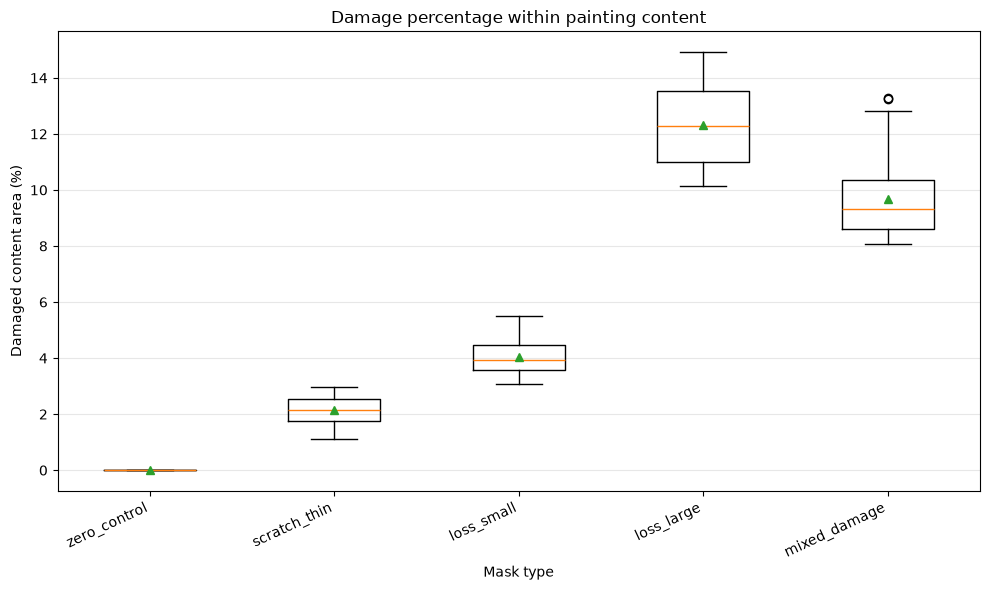

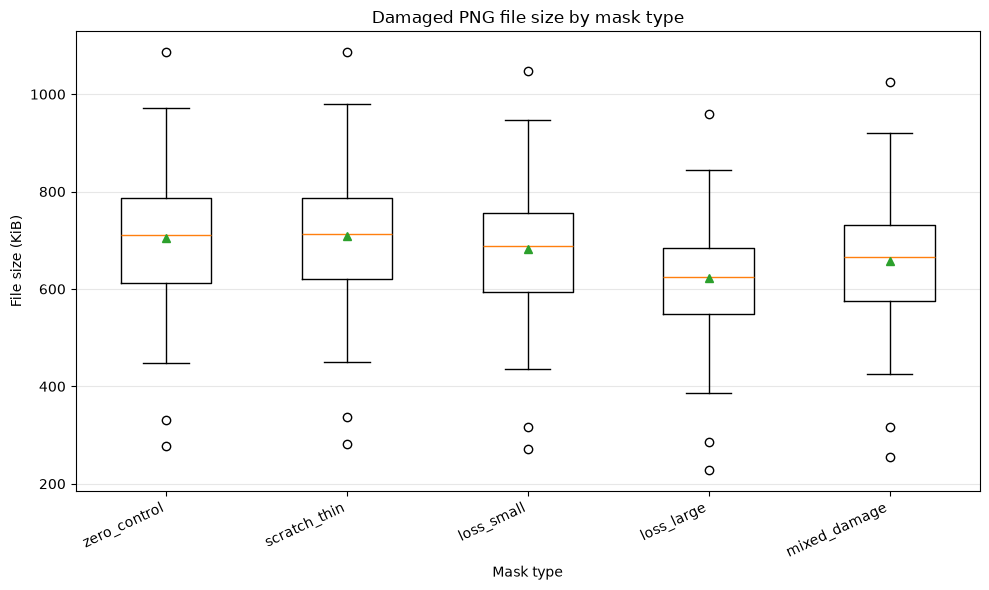

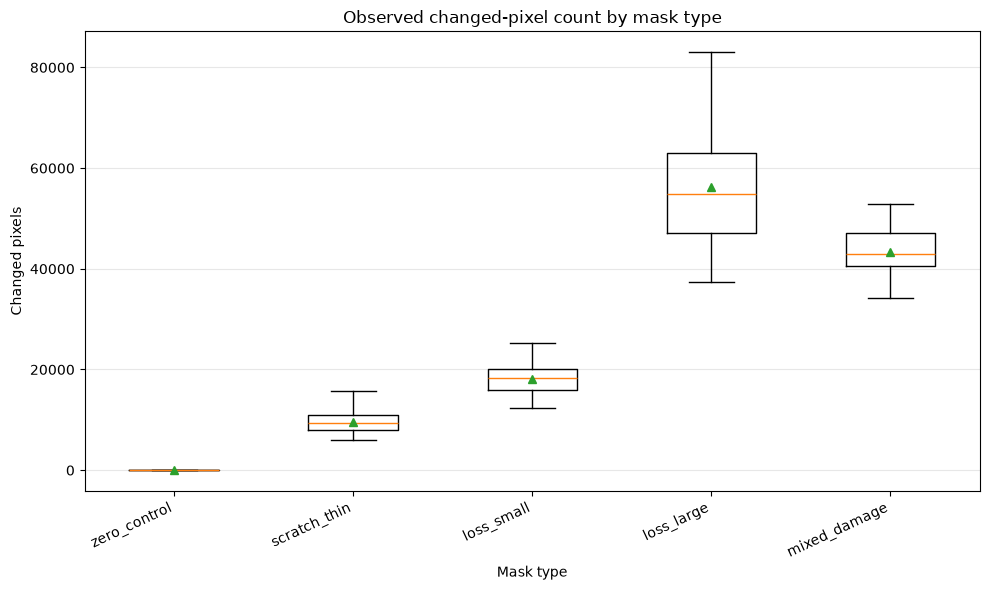

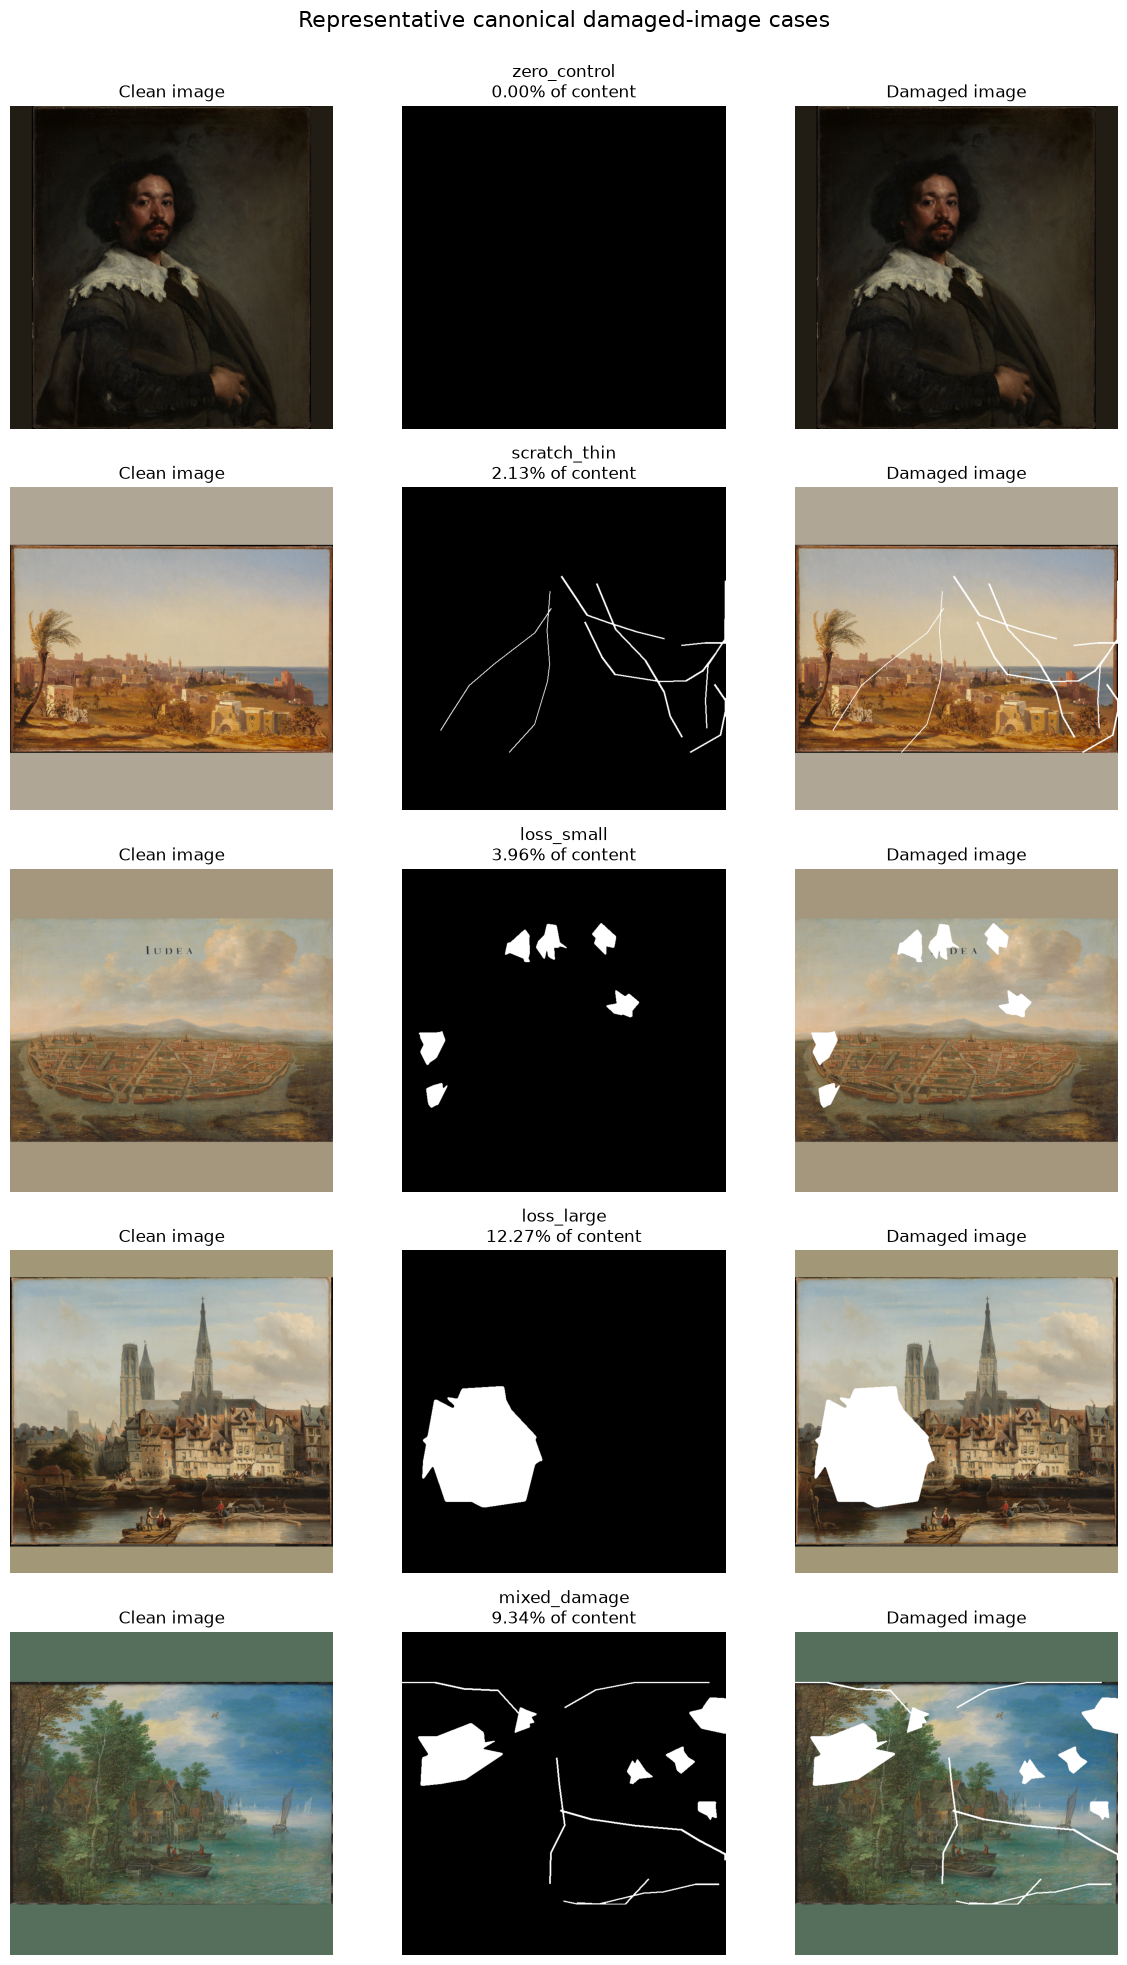

,figure_name,figure_path,exists,size_bytes
0,one_painting_damage_generation_test.png,outputs\figures\damage_creation\one_painting_d...,True,9032485
1,damage_percentage_by_mask_type.png,outputs\figures\damage_creation\damage_percent...,True,127769
2,damaged_file_size_by_mask_type.png,outputs\figures\damage_creation\damaged_file_s...,True,134130
3,changed_pixels_by_mask_type.png,outputs\figures\damage_creation\changed_pixels...,True,125067
4,representative_damage_examples.png,outputs\figures\damage_creation\representative...,True,8830699



Canonical damage figures generated and verified.


In [12]:
# Generate canonical damage-creation figures

damage_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)


damage_percentage_figure_path = (
    damage_figure_dir
    / "damage_percentage_by_mask_type.png"
)

damaged_file_size_figure_path = (
    damage_figure_dir
    / "damaged_file_size_by_mask_type.png"
)

changed_pixel_figure_path = (
    damage_figure_dir
    / "changed_pixels_by_mask_type.png"
)

representative_damage_figure_path = (
    damage_figure_dir
    / "representative_damage_examples.png"
)


damage_plot_df = damaged_metadata_df.copy()


damage_plot_df[
    "mask_type"
] = pd.Categorical(
    damage_plot_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


damage_plot_df = (
    damage_plot_df
    .sort_values(
        [
            "mask_type",
            "painting_id",
            "case_id",
        ],
        kind="stable",
    )
)


damage_percentage_groups = [
    damage_plot_df.loc[
        damage_plot_df[
            "mask_type"
        ]
        == mask_type,
        "damaged_area_percentage_content",
    ]
    .dropna()
    .to_numpy()
    for mask_type in configured_mask_types
]


figure, axis = plt.subplots(
    figsize=(10, 6)
)


axis.boxplot(
    damage_percentage_groups,
    showmeans=True,
)


axis.set_xticks(
    range(
        1,
        len(configured_mask_types) + 1,
    )
)

axis.set_xticklabels(
    configured_mask_types,
    rotation=25,
    ha="right",
)

axis.set_title(
    "Damage percentage within painting content"
)

axis.set_xlabel(
    "Mask type"
)

axis.set_ylabel(
    "Damaged content area (%)"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    damage_percentage_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


damaged_file_size_groups = [
    (
        damage_plot_df.loc[
            damage_plot_df[
                "mask_type"
            ]
            == mask_type,
            "damaged_file_size_bytes",
        ]
        .dropna()
        .to_numpy()
        / 1024
    )
    for mask_type in configured_mask_types
]


figure, axis = plt.subplots(
    figsize=(10, 6)
)


axis.boxplot(
    damaged_file_size_groups,
    showmeans=True,
)


axis.set_xticks(
    range(
        1,
        len(configured_mask_types) + 1,
    )
)

axis.set_xticklabels(
    configured_mask_types,
    rotation=25,
    ha="right",
)

axis.set_title(
    "Damaged PNG file size by mask type"
)

axis.set_xlabel(
    "Mask type"
)

axis.set_ylabel(
    "File size (KiB)"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    damaged_file_size_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


changed_pixel_plot_df = (
    damage_application_validation_df
    .copy()
)


changed_pixel_plot_df[
    "mask_type"
] = pd.Categorical(
    changed_pixel_plot_df[
        "mask_type"
    ],
    categories=configured_mask_types,
    ordered=True,
)


changed_pixel_groups = [
    changed_pixel_plot_df.loc[
        changed_pixel_plot_df[
            "mask_type"
        ]
        == mask_type,
        "changed_pixel_count",
    ]
    .dropna()
    .to_numpy()
    for mask_type in configured_mask_types
]


figure, axis = plt.subplots(
    figsize=(10, 6)
)


axis.boxplot(
    changed_pixel_groups,
    showmeans=True,
)


axis.set_xticks(
    range(
        1,
        len(configured_mask_types) + 1,
    )
)

axis.set_xticklabels(
    configured_mask_types,
    rotation=25,
    ha="right",
)

axis.set_title(
    "Observed changed-pixel count by mask type"
)

axis.set_xlabel(
    "Mask type"
)

axis.set_ylabel(
    "Changed pixels"
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    changed_pixel_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


representative_rows = []


for mask_type in configured_mask_types:
    mask_type_rows_df = (
        damage_plot_df.loc[
            damage_plot_df[
                "mask_type"
            ]
            == mask_type
        ]
        .copy()
    )

    if mask_type_rows_df.empty:
        continue

    target_damage_percentage = (
        mask_type_rows_df[
            "damaged_area_percentage_content"
        ]
        .median()
    )

    mask_type_rows_df[
        "distance_from_median_damage"
    ] = (
        mask_type_rows_df[
            "damaged_area_percentage_content"
        ]
        - target_damage_percentage
    ).abs()

    representative_rows.append(
        mask_type_rows_df
        .sort_values(
            [
                "distance_from_median_damage",
                "painting_id",
                "case_id",
            ],
            kind="stable",
        )
        .iloc[0]
    )


representative_damage_df = pd.DataFrame(
    representative_rows
)


if (
    len(representative_damage_df)
    != expected_mask_type_count
):
    raise RuntimeError(
        "Could not select one representative "
        "damage case for every configured mask type."
    )


representative_figure, representative_axes = (
    plt.subplots(
        len(representative_damage_df),
        3,
        figsize=(
            12,
            4
            * len(
                representative_damage_df
            ),
        ),
    )
)


if len(representative_damage_df) == 1:
    representative_axes = np.expand_dims(
        representative_axes,
        axis=0,
    )


for row_index, representative_row in (
    representative_damage_df
    .reset_index(drop=True)
    .iterrows()
):
    clean_path = Path(
        str(
            representative_row[
                "clean_path"
            ]
        )
    )

    mask_path = Path(
        str(
            representative_row[
                "mask_path"
            ]
        )
    )

    damaged_path = Path(
        str(
            representative_row[
                "damaged_path"
            ]
        )
    )


    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )

    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT
            / mask_path
        )

    if not damaged_path.is_absolute():
        damaged_path = (
            PROJECT_ROOT
            / damaged_path
        )


    for required_path in [
        clean_path,
        mask_path,
        damaged_path,
    ]:
        if not required_path.exists():
            raise FileNotFoundError(
                "Representative damage source "
                f"is missing: {required_path}"
            )


    with Image.open(
        clean_path
    ) as opened_clean_image:
        clean_array = np.asarray(
            opened_clean_image.convert(
                "RGB"
            )
        )


    with Image.open(
        mask_path
    ) as opened_mask_image:
        mask_array = np.asarray(
            opened_mask_image.convert(
                "L"
            )
        )


    with Image.open(
        damaged_path
    ) as opened_damaged_image:
        damaged_array = np.asarray(
            opened_damaged_image.convert(
                "RGB"
            )
        )


    representative_axes[
        row_index,
        0,
    ].imshow(
        clean_array
    )

    representative_axes[
        row_index,
        0,
    ].set_title(
        "Clean image"
    )


    representative_axes[
        row_index,
        1,
    ].imshow(
        mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    representative_axes[
        row_index,
        1,
    ].set_title(
        (
            f"{representative_row['mask_type']}\n"
            f"{float(representative_row['damaged_area_percentage_content']):.2f}% "
            "of content"
        )
    )


    representative_axes[
        row_index,
        2,
    ].imshow(
        damaged_array
    )

    representative_axes[
        row_index,
        2,
    ].set_title(
        "Damaged image"
    )


    for representative_axis in (
        representative_axes[
            row_index
        ]
    ):
        representative_axis.axis(
            "off"
        )


representative_figure.suptitle(
    "Representative canonical damaged-image cases",
    fontsize=16,
)

representative_figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.98,
    ]
)

representative_figure.savefig(
    representative_damage_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(
    representative_figure
)


damage_figure_paths = [
    test_visualisation_path,
    damage_percentage_figure_path,
    damaged_file_size_figure_path,
    changed_pixel_figure_path,
    representative_damage_figure_path,
]


damage_figure_manifest_records = []


for figure_path in damage_figure_paths:
    figure_exists = (
        figure_path.exists()
    )

    figure_size_bytes = (
        figure_path.stat().st_size
        if figure_exists
        else 0
    )

    damage_figure_manifest_records.append(
        {
            "figure_name": figure_path.name,
            "figure_path": str(
                figure_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": figure_exists,
            "size_bytes": figure_size_bytes,
        }
    )


damage_figure_manifest_df = pd.DataFrame(
    damage_figure_manifest_records
)


display(
    damage_figure_manifest_df
)


invalid_damage_figures_df = (
    damage_figure_manifest_df.loc[
        (
            ~damage_figure_manifest_df[
                "exists"
            ].astype(bool)
        )
        |
        (
            damage_figure_manifest_df[
                "size_bytes"
            ]
            <= 0
        )
    ]
    .copy()
)


if not invalid_damage_figures_df.empty:
    display(
        invalid_damage_figures_df
    )

    raise RuntimeError(
        "One or more canonical damage figures "
        "are missing or empty."
    )


print(
    "\nCanonical damage figures generated "
    "and verified."
)

In [13]:
# Generate canonical Notebook 04 reports

from textwrap import dedent


report_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)


damage_manifest = {
    "stage": "04_damage_creation",
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "config_version": config_version,
    "experiment": {
        "name": experiment_name,
        "version": experiment_version,
    },
    "generator": {
        "name": damage_generator_name,
        "version": damage_generator_version,
    },
    "configuration": {
        "target_size": target_size,
        "fill_strategy": damage_fill_strategy,
        "fill_color_rgb": list(
            damage_fill_color
        ),
        "configured_mask_types": (
            configured_mask_types
        ),
    },
    "counts": {
        "paintings": int(
            damaged_metadata_df[
                "painting_id"
            ].nunique()
        ),
        "mask_types": int(
            damaged_metadata_df[
                "mask_type"
            ].nunique()
        ),
        "damage_cases": int(
            len(
                damaged_metadata_df
            )
        ),
        "damaged_files": int(
            len(
                actual_damaged_filename_set
            )
        ),
        "stale_files_removed": int(
            len(
                stale_damaged_filenames_before_generation
            )
        ),
    },
    "validation": {
        "generation_status_passed": bool(
            damaged_metadata_df[
                "status"
            ]
            .astype(str)
            .eq("ok")
            .all()
        ),
        "saved_file_validation_passed": bool(
            damaged_file_validation_df[
                "validation_passed"
            ]
            .astype(bool)
            .all()
        ),
        "damage_application_validation_passed": bool(
            damage_application_validation_df[
                "validation_passed"
            ]
            .astype(bool)
            .all()
        ),
        "inventory_audit_passed": bool(
            damage_creation_audit_df[
                "passed"
            ]
            .astype(bool)
            .all()
        ),
        "outside_mask_changed_pixels": int(
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "inside_mask_not_fill_pixels": int(
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
    },
    "canonical_artifacts": {
        "damaged_metadata": str(
            damaged_metadata_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "damaged_image_directory": str(
            damaged_image_dir.relative_to(
                PROJECT_ROOT
            )
        ),
        "audit": str(
            damage_creation_audit_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "report": str(
            damage_report_path.relative_to(
                PROJECT_ROOT
            )
        ),
        "figures": (
            damage_figure_manifest_df[
                "figure_path"
            ]
            .astype(str)
            .tolist()
        ),
    },
    "mask_type_summary": (
        damage_case_summary_df
        .assign(
            mask_type=lambda dataframe: (
                dataframe[
                    "mask_type"
                ]
                .astype("object")
                .astype(str)
            )
        )
        .replace(
            {
                np.nan: None,
            }
        )
        .to_dict(
            orient="records"
        )
    ),
}


temporary_damage_manifest_path = (
    damage_manifest_path.with_suffix(
        ".tmp.json"
    )
)


with temporary_damage_manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        damage_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )


temporary_damage_manifest_path.replace(
    damage_manifest_path
)


report_lines = [
    "# Canonical Damaged-Image Generation Report",
    "",
    "## Experiment",
    "",
    f"- Experiment: `{experiment_name}`",
    f"- Experiment version: `{experiment_version}`",
    f"- Configuration version: `{config_version}`",
    (
        f"- Generator: `{damage_generator_name}` "
        f"version `{damage_generator_version}`"
    ),
    (
        f"- Fill strategy: `{damage_fill_strategy}`"
    ),
    (
        f"- Fill colour: RGB "
        f"`{damage_fill_color}`"
    ),
    (
        f"- Output dimensions: "
        f"`{target_size} × {target_size}`"
    ),
    "",
    "## Dataset",
    "",
    (
        f"- Paintings: "
        f"{damaged_metadata_df['painting_id'].nunique()}"
    ),
    (
        f"- Mask types: "
        f"{damaged_metadata_df['mask_type'].nunique()}"
    ),
    (
        f"- Damage cases: "
        f"{len(damaged_metadata_df)}"
    ),
    (
        f"- Damaged PNG files: "
        f"{len(actual_damaged_filename_set)}"
    ),
    "",
    "## Mask-type summary",
    "",
]


for summary_row in (
    damage_case_summary_df.itertuples(
        index=False
    )
):
    report_lines.append(
        (
            f"- `{summary_row.mask_type}`: "
            f"{int(summary_row.case_count)} cases; "
            f"mean damaged content area "
            f"{float(summary_row.mean_damage_percentage_content):.4f}%; "
            f"mean damaged pixels "
            f"{float(summary_row.mean_damaged_pixels):.2f}"
        )
    )


report_lines.extend(
    [
        "",
        "## Validation",
        "",
        (
            "- Every damaged output was reloaded "
            "and validated as a readable RGB PNG "
            f"with dimensions {target_size} × {target_size}."
        ),
        (
            "- No pixels outside the canonical "
            "binary masks were changed."
        ),
        (
            "- Every pixel inside each mask was set "
            "to the configured damage-fill colour."
        ),
        (
            "- Damaged-pixel counts matched the "
            "canonical mask metadata."
        ),
        (
            "- Zero-control outputs remained "
            "identical to their clean sources."
        ),
        (
            "- SHA-256 checksums were recorded for "
            "clean images, masks, and damaged images."
        ),
        (
            "- Missing, duplicate, stale, and "
            "orphaned damaged-image files were audited."
        ),
        "",
        "## Canonical artifacts",
        "",
        (
            f"- Damaged images: "
            f"`{damaged_image_dir.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Metadata: "
            f"`{damaged_metadata_path.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Audit: "
            f"`{damage_creation_audit_path.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- Figures: "
            f"`{damage_figure_dir.relative_to(PROJECT_ROOT)}`"
        ),
        (
            f"- JSON manifest: "
            f"`{damage_manifest_path.relative_to(PROJECT_ROOT)}`"
        ),
        "",
        "## Interpretation note",
        "",
        dedent(
            """
            The numerically changed-pixel count can be smaller than the
            binary-mask pixel count when a clean source pixel already has
            exactly the configured fill colour. This is not a generation
            failure. The authoritative requirements are that all pixels
            outside the mask remain unchanged and all pixels inside the mask
            equal the configured fill colour.
            """
        ).strip(),
    ]
)


temporary_damage_report_path = (
    damage_report_path.with_suffix(
        ".tmp.md"
    )
)


temporary_damage_report_path.write_text(
    "\n".join(
        report_lines
    ),
    encoding="utf-8",
)


temporary_damage_report_path.replace(
    damage_report_path
)


report_artifact_validation_df = pd.DataFrame(
    [
        {
            "artifact": str(
                damage_manifest_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                damage_manifest_path.exists()
            ),
            "size_bytes": (
                damage_manifest_path.stat().st_size
                if damage_manifest_path.exists()
                else 0
            ),
        },
        {
            "artifact": str(
                damage_report_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                damage_report_path.exists()
            ),
            "size_bytes": (
                damage_report_path.stat().st_size
                if damage_report_path.exists()
                else 0
            ),
        },
    ]
)


display(
    report_artifact_validation_df
)


invalid_report_artifacts_df = (
    report_artifact_validation_df.loc[
        (
            ~report_artifact_validation_df[
                "exists"
            ].astype(bool)
        )
        |
        (
            report_artifact_validation_df[
                "size_bytes"
            ]
            <= 0
        )
    ]
    .copy()
)


if not invalid_report_artifacts_df.empty:
    display(
        invalid_report_artifacts_df
    )

    raise RuntimeError(
        "One or more Notebook 04 reports "
        "are missing or empty."
    )


print(
    "\nCanonical Notebook 04 reports "
    "generated and verified."
)

print(
    damage_manifest_path
)

print(
    damage_report_path
)

,artifact,exists,size_bytes
0,outputs\reports\damage_creation_metadata.json,True,5087
1,outputs\reports\damage_creation_report.md,True,2154



Canonical Notebook 04 reports generated and verified.
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_creation_metadata.json
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_creation_report.md


In [14]:
# Perform final Notebook 04 audit and clean temporary outputs

required_final_artifact_paths = [
    damaged_metadata_path,
    damage_creation_audit_path,
    damage_manifest_path,
    damage_report_path,
    *damage_figure_paths,
]


final_artifact_records = []


for artifact_path in (
    required_final_artifact_paths
):
    artifact_exists = (
        artifact_path.exists()
    )

    artifact_size_bytes = (
        artifact_path.stat().st_size
        if artifact_exists
        else 0
    )

    final_artifact_records.append(
        {
            "artifact": str(
                artifact_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": artifact_exists,
            "size_bytes": artifact_size_bytes,
        }
    )


final_artifact_validation_df = pd.DataFrame(
    final_artifact_records
)


final_notebook_audit_records = [
    {
        "audit_section": "final",
        "check": "expected_metadata_rows",
        "observed": len(
            damaged_metadata_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(damaged_metadata_df)
            == expected_case_count
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "expected_unique_paintings",
        "observed": int(
            damaged_metadata_df[
                "painting_id"
            ].nunique()
        ),
        "expected": expected_painting_count,
        "passed": (
            damaged_metadata_df[
                "painting_id"
            ].nunique()
            == expected_painting_count
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "expected_unique_mask_types",
        "observed": int(
            damaged_metadata_df[
                "mask_type"
            ].nunique()
        ),
        "expected": expected_mask_type_count,
        "passed": (
            damaged_metadata_df[
                "mask_type"
            ].nunique()
            == expected_mask_type_count
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "expected_damaged_files",
        "observed": len(
            actual_damaged_filename_set
        ),
        "expected": expected_case_count,
        "passed": (
            len(
                actual_damaged_filename_set
            )
            == expected_case_count
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "all_generation_status_ok",
        "observed": int(
            damaged_metadata_df[
                "status"
            ]
            .astype(str)
            .ne("ok")
            .sum()
        ),
        "expected": 0,
        "passed": bool(
            damaged_metadata_df[
                "status"
            ]
            .astype(str)
            .eq("ok")
            .all()
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "all_saved_files_valid",
        "observed": int(
            (
                ~damaged_file_validation_df[
                    "validation_passed"
                ].astype(bool)
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            damaged_file_validation_df[
                "validation_passed"
            ]
            .astype(bool)
            .all()
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "all_damage_applications_valid",
        "observed": int(
            (
                ~damage_application_validation_df[
                    "validation_passed"
                ].astype(bool)
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            damage_application_validation_df[
                "validation_passed"
            ]
            .astype(bool)
            .all()
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "outside_mask_changed_pixels",
        "observed": int(
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "outside_mask_changed_pixels"
            ].sum()
            == 0
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "inside_mask_fill_failures",
        "observed": int(
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
        ),
        "expected": 0,
        "passed": (
            damage_application_validation_df[
                "inside_mask_not_fill_pixels"
            ].sum()
            == 0
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "missing_final_artifacts",
        "observed": int(
            (
                ~final_artifact_validation_df[
                    "exists"
                ].astype(bool)
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            final_artifact_validation_df[
                "exists"
            ]
            .astype(bool)
            .all()
        ),
        "details": "",
    },
    {
        "audit_section": "final",
        "check": "empty_final_artifacts",
        "observed": int(
            (
                final_artifact_validation_df[
                    "size_bytes"
                ]
                <= 0
            ).sum()
        ),
        "expected": 0,
        "passed": bool(
            (
                final_artifact_validation_df[
                    "size_bytes"
                ]
                > 0
            ).all()
        ),
        "details": "",
    },
]


final_notebook_audit_df = pd.DataFrame(
    final_notebook_audit_records
)


damage_creation_audit_df = (
    pd.concat(
        [
            damage_creation_audit_df.loc[
                damage_creation_audit_df[
                    "audit_section"
                ]
                != "final"
            ],
            final_notebook_audit_df,
        ],
        ignore_index=True,
    )
)


damage_creation_audit_df[
    "passed"
] = (
    damage_creation_audit_df[
        "passed"
    ]
    .astype(bool)
)


damage_creation_audit_df.to_csv(
    damage_creation_audit_path,
    index=False,
)


print("Final artifact validation")
print("-------------------------")

display(
    final_artifact_validation_df
)


print("\nFinal Notebook 04 audit")
print("-----------------------")

display(
    final_notebook_audit_df
)


failed_final_notebook_audit_df = (
    final_notebook_audit_df.loc[
        ~final_notebook_audit_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_final_notebook_audit_df.empty:
    display(
        failed_final_notebook_audit_df
    )

    raise RuntimeError(
        "Final canonical Notebook 04 audit failed."
    )


if temporary_damage_test_dir.exists():
    shutil.rmtree(
        temporary_damage_test_dir
    )


if temporary_damage_test_dir.exists():
    raise RuntimeError(
        "Temporary one-painting damage test "
        "directory was not removed."
    )


temporary_file_patterns = [
    "*.tmp.csv",
    "*.tmp.json",
    "*.tmp.md",
]


remaining_temporary_files = []


for search_directory in [
    processed_metadata_dir,
    damage_creation_output_dir,
    report_output_dir,
]:
    for temporary_file_pattern in (
        temporary_file_patterns
    ):
        remaining_temporary_files.extend(
            search_directory.glob(
                temporary_file_pattern
            )
        )


remaining_temporary_files = sorted(
    set(
        remaining_temporary_files
    )
)


if remaining_temporary_files:
    raise RuntimeError(
        "Temporary Notebook 04 files remain: "
        f"{remaining_temporary_files}"
    )


reloaded_final_audit_df = pd.read_csv(
    damage_creation_audit_path
)


if (
    len(reloaded_final_audit_df)
    != len(damage_creation_audit_df)
):
    raise RuntimeError(
        "Reloaded canonical audit row count "
        "does not match the saved audit."
    )


if not (
    reloaded_final_audit_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    failed_reloaded_audit_df = (
        reloaded_final_audit_df.loc[
            ~reloaded_final_audit_df[
                "passed"
            ].astype(bool)
        ]
        .copy()
    )

    display(
        failed_reloaded_audit_df
    )

    raise RuntimeError(
        "Reloaded canonical damage audit "
        "contains failed checks."
    )


print(
    "\nTemporary test outputs removed."
)

print(
    "Single canonical audit CSV verified:"
)

print(
    damage_creation_audit_path
)

print(
    "\nNotebook 04 canonical damaged-image "
    "generation completed successfully."
)

Final artifact validation
-------------------------


,artifact,exists,size_bytes
0,data\processed\metadata\metadata_damaged_image...,True,165917
1,outputs\04_damage_creation\damage_creation_aud...,True,1125
2,outputs\reports\damage_creation_metadata.json,True,5087
3,outputs\reports\damage_creation_report.md,True,2154
4,outputs\figures\damage_creation\one_painting_d...,True,9032485
5,outputs\figures\damage_creation\damage_percent...,True,127769
6,outputs\figures\damage_creation\damaged_file_s...,True,134130
7,outputs\figures\damage_creation\changed_pixels...,True,125067
8,outputs\figures\damage_creation\representative...,True,8830699



Final Notebook 04 audit
-----------------------


,audit_section,check,observed,expected,passed,details
0,final,expected_metadata_rows,250,250,True,
1,final,expected_unique_paintings,50,50,True,
2,final,expected_unique_mask_types,5,5,True,
3,final,expected_damaged_files,250,250,True,
4,final,all_generation_status_ok,0,0,True,
5,final,all_saved_files_valid,0,0,True,
6,final,all_damage_applications_valid,0,0,True,
7,final,outside_mask_changed_pixels,0,0,True,
8,final,inside_mask_fill_failures,0,0,True,
9,final,missing_final_artifacts,0,0,True,



Temporary test outputs removed.
Single canonical audit CSV verified:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\04_damage_creation\damage_creation_audit.csv

Notebook 04 canonical damaged-image generation completed successfully.


# Notebook Complete

## Canonical outputs

### Damaged-image dataset

- `data/processed/damaged/*.png`
- `data/processed/metadata/metadata_damaged_images.csv`

### Audit

- `outputs/04_damage_creation/damage_creation_audit.csv`

### Figures

- `outputs/figures/damage_creation/one_painting_damage_generation_test.png`
- `outputs/figures/damage_creation/damage_percentage_by_mask_type.png`
- `outputs/figures/damage_creation/damaged_file_size_by_mask_type.png`
- `outputs/figures/damage_creation/changed_pixels_by_mask_type.png`
- `outputs/figures/damage_creation/representative_damage_examples.png`

### Reports

- `outputs/reports/damage_creation_metadata.json`
- `outputs/reports/damage_creation_report.md`

## Validation completed

- Canonical processed-image metadata validation
- Canonical mask metadata validation
- One-painting generation test
- Full damaged-image generation
- Output-dimension and RGB PNG validation
- Saved-file reload validation
- Clean, mask, and damaged-image checksum validation
- Exact preservation outside the mask
- Correct fill values inside the mask
- Mask-pixel count verification
- Changed-pixel count verification
- Zero-control identity verification
- Missing-file detection
- Duplicate-file detection
- Stale-file removal
- Orphaned-file detection
- Final artifact validation
- Temporary-output cleanup

The damaged-image dataset is now the canonical input for the restoration notebooks beginning with the OpenCV Telea baseline.